In [1]:
import numpy as np
import pandas as pd 
import os
import re
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
from sklearn.preprocessing import minmax_scale
import IPython.display as ipd
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, recall_score

In [2]:
import pandas as pd
dataf = pd.read_csv('/kaggle/input/mfcc-of-slurred-vocal/MFCCoutput.csv')
dataf = dataf.drop(columns=dataf.columns[0], axis = 1)
dataf.head()

,0,1,2,3,4,5,6,7,8,9,...,119,120,121,122,123,124,125,126,127,class
0,-398.97055,92.846680,-6.212745,19.836878,-3.015201,9.478265,5.134083,6.716100,1.437088,0.016323,...,0.018726,-0.244671,-0.650705,-0.262222,0.137795,-0.539087,-0.257223,-0.230522,-0.188446,1.0
1,-232.39255,115.044525,-21.028315,39.190132,-17.016842,7.619745,-2.724971,4.140653,-1.230497,-0.977595,...,0.197640,0.564010,0.166091,-0.022294,0.257573,0.168772,0.264451,-0.257519,-0.390595,1.0
2,-466.48450,89.272385,-8.458461,30.776363,-11.168960,18.305796,0.989266,10.417193,0.574027,1.563966,...,0.232031,0.074036,0.237405,0.154122,0.281900,0.768758,-0.073312,0.096406,0.285212,1.0
3,-466.73505,62.805060,12.439709,29.304922,12.614448,9.676723,1.418015,13.074185,0.037665,3.573357,...,0.408432,-0.018611,-0.274066,0.071348,0.231881,0.456909,0.000649,-0.379244,-0.105873,1.0
4,-426.44970,80.985410,-4.792509,36.350883,-0.092283,19.156744,-5.060070,10.123955,2.196594,1.254182,...,-0.064134,0.120973,0.070115,0.138273,0.084424,0.080933,-0.295089,-0.199056,0.120445,1.0


In [3]:
dataf.loc[dataf['class']=='non_dysarthria','class'] = 0.0
dataf.loc[dataf['class']=='dysarthria','class'] = 1.0
dataf['class'] = dataf['class'].astype(float)

X = dataf.iloc[:,:-1].values
y = dataf.iloc[:,-1]

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)


In [5]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from collections import defaultdict
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier, VotingClassifier

In [6]:
hyperparameters_RFC = {'n_estimators': 600, 'max_depth': 90, 'min_samples_split': 6, 'min_samples_leaf': 3,
                       'max_features': 'sqrt', 'bootstrap': False, 'criterion': 'entropy'}

hyperparameters_XGB = {'max_depth': 9,
                       'min_child_weight': 1,
                       'learning_rate': 0.2,
                       'subsample': 0.8,
                       'colsample_bytree': 1.0,
                       'gamma': 0,
                       'n_estimators': 600,
                       'use_label_encoder': False,
                       'eval_metric': 'rmse',
                       'objective': 'binary:logistic'}

hyperparameters_CB = {'bagging_temperature': 0.8607305832563434, 'bootstrap_type': 'MVS',
                      'colsample_bylevel': 0.917411003148779,
                      'depth': 8, 'grow_policy': 'SymmetricTree', 'iterations': 918, 'l2_leaf_reg': 8,
                      'learning_rate': 0.29287291117375575, 'max_bin': 231, 'min_data_in_leaf': 9, 'od_type': 'Iter',
                      'od_wait': 21, 'one_hot_max_size': 7, 'random_strength': 0.6963042728397884,
                      'scale_pos_weight': 1.924541179848884, 'subsample': 0.6480869299533999}

rf = RandomForestClassifier(**hyperparameters_RFC, random_state=150)
cb = CatBoostClassifier(**hyperparameters_CB)
xgb = XGBClassifier(**hyperparameters_XGB)

In [7]:
import numpy as np
import pandas as pd
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import ExtraTreesClassifier

# Assuming you have a feature matrix 'X' and target labels 'y'
X = dataf.iloc[:, :-1]  # All columns except the last one
y = dataf.iloc[:, -1]   # Last column as target

# Define classifiers with hyperparameters
cb = CatBoostClassifier()  # Suppress CatBoost logs
lgbm = LGBMClassifier()
et = ExtraTreesClassifier()

# Step 1: Train the classifiers
cb.fit(X, y)
lgbm.fit(X, y)
et.fit(X, y)

# Step 2: Get feature importance scores
cb_importance = cb.get_feature_importance()
lgbm_importance = lgbm.feature_importances_
et_importance = et.feature_importances_

# Step 3: Convert to DataFrame
feature_names = dataf.columns[:-1]  # Assuming last column is 'class'
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'CB_Importance': cb_importance,
    'LGBM_Importance': lgbm_importance,
    'ET_Importance': et_importance
})

# Normalize importance scores 
importance_df[['CB_Importance', 'LGBM_Importance', 'ET_Importance']] = \
    importance_df[['CB_Importance', 'LGBM_Importance', 'ET_Importance']].apply(lambda x: x / np.max(x))

# Compute average importance
importance_df['Avg_Importance'] = importance_df[['CB_Importance', 'LGBM_Importance', 'ET_Importance']].mean(axis=1)

# Sort by Avg_Importance
importance_df = importance_df.sort_values(by='Avg_Importance', ascending=False).reset_index(drop=True)

importance_df.to_csv("feature_importance_basic.csv", index=False)

# # Step 7: Assign Fibonacci weights
# def fibonacci(n):
#     fib_series = [1, 1]
#     for _ in range(n-2):
#         fib_series.append(fib_series[-1] + fib_series[-2])
#     return fib_series

# fib_weights = fibonacci(len(importance_df))

# # Compute final ranking score
# importance_df['Fibonacci_Weight'] = fib_weights
# importance_df['Final_Rank_Score'] = importance_df['Avg_Importance'] * importance_df['Fibonacci_Weight']

# # Sort based on Final Rank Score
# importance_df = importance_df.sort_values(by='Final_Rank_Score', ascending=False).reset_index(drop=True)

# # Top ranked features
# print(importance_df[['Feature', 'Final_Rank_Score']].head(20))


Learning rate set to 0.019232
0:	learn: 0.6571122	total: 75.7ms	remaining: 1m 15s
1:	learn: 0.6288094	total: 90.9ms	remaining: 45.4s
2:	learn: 0.6072127	total: 106ms	remaining: 35.2s
3:	learn: 0.5862682	total: 121ms	remaining: 30.1s
4:	learn: 0.5671602	total: 135ms	remaining: 26.9s
5:	learn: 0.5487795	total: 151ms	remaining: 25s
6:	learn: 0.5314452	total: 167ms	remaining: 23.6s
7:	learn: 0.5141469	total: 182ms	remaining: 22.6s
8:	learn: 0.4976034	total: 198ms	remaining: 21.8s
9:	learn: 0.4763892	total: 214ms	remaining: 21.2s
10:	learn: 0.4610827	total: 229ms	remaining: 20.6s
11:	learn: 0.4443572	total: 244ms	remaining: 20.1s
12:	learn: 0.4310225	total: 259ms	remaining: 19.7s
13:	learn: 0.4156707	total: 274ms	remaining: 19.3s
14:	learn: 0.4034640	total: 290ms	remaining: 19s
15:	learn: 0.3913176	total: 306ms	remaining: 18.8s
16:	learn: 0.3811392	total: 321ms	remaining: 18.6s
17:	learn: 0.3717761	total: 337ms	remaining: 18.4s
18:	learn: 0.3628075	total: 353ms	remaining: 18.2s
19:	learn: 0

In [8]:
ranked_features=importance_df

In [9]:
importance_df = pd.read_csv('feature_importance_basic.csv')
print(importance_df.head())

   Feature  CB_Importance  LGBM_Importance  ET_Importance  Avg_Importance
0        0       1.000000         1.000000       1.000000        1.000000
1       36       0.642909         0.740157       0.861020        0.748029
2       82       0.484306         0.732283       0.792502        0.669697
3       49       0.290911         0.787402       0.853955        0.644089
4       12       0.293238         0.464567       0.908392        0.555399


In [10]:
print(importance_df.isna().sum())

Feature            0
CB_Importance      0
LGBM_Importance    0
ET_Importance      0
Avg_Importance     0
dtype: int64


In [11]:
ranked_features

,Feature,CB_Importance,LGBM_Importance,ET_Importance,Avg_Importance
0,0,1.000000,1.000000,1.000000,1.000000
1,36,0.642909,0.740157,0.861020,0.748029
2,82,0.484306,0.732283,0.792502,0.669697
3,49,0.290911,0.787402,0.853955,0.644089
4,12,0.293238,0.464567,0.908392,0.555399
...,...,...,...,...,...
123,122,0.001554,0.023622,0.137302,0.054159
124,4,0.003435,0.007874,0.120497,0.043935
125,73,0.005222,0.000000,0.108887,0.038037
126,110,0.003917,0.023622,0.067019,0.031519


In [12]:
dataf

,0,1,2,3,4,5,6,7,8,9,...,119,120,121,122,123,124,125,126,127,class
0,-398.97055,92.846680,-6.212745,19.836878,-3.015201,9.478265,5.134083,6.716100,1.437088,0.016323,...,0.018726,-0.244671,-0.650705,-0.262222,0.137795,-0.539087,-0.257223,-0.230522,-0.188446,1.0
1,-232.39255,115.044525,-21.028315,39.190132,-17.016842,7.619745,-2.724971,4.140653,-1.230497,-0.977595,...,0.197640,0.564010,0.166091,-0.022294,0.257573,0.168772,0.264451,-0.257519,-0.390595,1.0
2,-466.48450,89.272385,-8.458461,30.776363,-11.168960,18.305796,0.989266,10.417193,0.574027,1.563966,...,0.232031,0.074036,0.237405,0.154122,0.281900,0.768758,-0.073312,0.096406,0.285212,1.0
3,-466.73505,62.805060,12.439709,29.304922,12.614448,9.676723,1.418015,13.074185,0.037665,3.573357,...,0.408432,-0.018611,-0.274066,0.071348,0.231881,0.456909,0.000649,-0.379244,-0.105873,1.0
4,-426.44970,80.985410,-4.792509,36.350883,-0.092283,19.156744,-5.060070,10.123955,2.196594,1.254182,...,-0.064134,0.120973,0.070115,0.138273,0.084424,0.080933,-0.295089,-0.199056,0.120445,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4309,-469.04440,118.562874,-6.434429,31.259987,-6.916942,28.232567,4.596171,10.801232,10.187455,2.826132,...,1.427834,1.057893,1.556124,0.044795,0.736732,-0.084226,-0.271552,0.629459,0.242347,1.0
4310,-341.55220,125.433670,-18.731533,38.031948,-17.117916,14.470189,0.926031,7.484399,4.782696,0.356445,...,1.192693,0.387493,0.853776,0.574696,0.120452,0.950003,0.213699,0.169374,0.082446,1.0
4311,-452.75305,124.908340,-12.018002,27.919792,-9.511669,26.848291,5.744361,11.316424,5.834333,3.948838,...,1.109973,1.165894,1.393030,-0.012943,0.496955,-0.252641,-0.252282,0.796462,0.615387,1.0
4312,-262.51575,121.906530,-20.538330,48.941536,-24.940454,35.154140,-8.200293,17.075691,7.877915,0.870777,...,1.850283,1.768507,0.825172,0.101314,-0.407541,-0.048040,0.122928,-0.037107,-0.407376,1.0


In [13]:
# Step 1: Sort importance_df by Avg_Importance descending
sorted_features = ranked_features.sort_values(by='Avg_Importance', ascending=False)['Feature'].tolist()

# Step 2: Rearrange dataf columns based on sorted features
dataf2 = dataf[sorted_features]


In [14]:
dataf2

,0,36,82,49,12,24,83,35,14,117,...,17,123,74,127,105,122,4,73,110,125
0,-398.97055,0.643070,-0.082618,-0.626069,-2.605149,0.169234,0.150909,0.996082,5.158936,-0.107622,...,-0.403323,0.137795,0.261442,-0.188446,0.881969,-0.262222,-3.015201,0.301149,1.308860,-0.257223
1,-232.39255,-2.081796,0.518272,-0.584924,-1.054728,-3.284457,-0.810806,0.056364,8.884685,0.169014,...,-0.775419,0.257573,-1.265496,-0.390595,0.508514,-0.022294,-17.016842,-0.027320,0.036457,0.264451
2,-466.48450,-0.686953,0.154127,1.862350,5.793727,0.856521,0.026485,2.896147,3.335157,0.387918,...,1.396552,0.281900,0.063773,0.285212,0.347298,0.154122,-11.168960,0.607886,0.899342,-0.073312
3,-466.73505,0.354227,0.893241,2.739482,6.860754,1.779491,0.105287,0.916992,-1.749699,0.521781,...,2.674563,0.231881,-0.292668,-0.105873,0.658468,0.071348,12.614448,0.610250,0.777924,0.000649
4,-426.44970,-0.146068,0.319562,0.793730,3.329647,-1.323783,1.188673,1.125068,2.997393,-0.113349,...,-1.877208,0.084424,0.709834,0.120445,1.218929,0.138273,-0.092283,2.272153,1.216608,-0.295089
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4309,-469.04440,0.667725,-1.150932,-1.681382,13.407104,-0.696209,-1.350081,5.842295,6.208955,0.020415,...,1.342123,0.736732,0.980667,0.242347,0.005896,0.044795,-6.916942,2.245116,1.172466,-0.271552
4310,-341.55220,3.166479,0.641081,-1.525722,7.693523,0.992836,-1.039040,5.976670,9.485500,0.446025,...,2.449379,0.120452,-1.859336,0.082446,0.503584,0.574696,-17.117916,0.519589,1.452361,0.213699
4311,-452.75305,-1.977218,-0.320168,-2.869868,12.195444,-2.294162,-0.665405,2.727275,5.591595,-0.045547,...,1.999068,0.496955,-0.371501,0.615387,0.234902,-0.012943,-9.511669,0.737324,0.813473,-0.252282
4312,-262.51575,-2.659099,-1.217482,-2.396534,10.282610,-0.292012,-2.985125,0.573411,7.236306,1.256466,...,2.735790,-0.407541,-2.635686,-0.407376,0.278844,0.101314,-24.940454,-1.482781,1.259492,0.122928


In [15]:
# Step 3: Add the 'class' column at the end
dataf2['class'] = dataf['class'].values

In [16]:
dataf2

,0,36,82,49,12,24,83,35,14,117,...,123,74,127,105,122,4,73,110,125,class
0,-398.97055,0.643070,-0.082618,-0.626069,-2.605149,0.169234,0.150909,0.996082,5.158936,-0.107622,...,0.137795,0.261442,-0.188446,0.881969,-0.262222,-3.015201,0.301149,1.308860,-0.257223,1.0
1,-232.39255,-2.081796,0.518272,-0.584924,-1.054728,-3.284457,-0.810806,0.056364,8.884685,0.169014,...,0.257573,-1.265496,-0.390595,0.508514,-0.022294,-17.016842,-0.027320,0.036457,0.264451,1.0
2,-466.48450,-0.686953,0.154127,1.862350,5.793727,0.856521,0.026485,2.896147,3.335157,0.387918,...,0.281900,0.063773,0.285212,0.347298,0.154122,-11.168960,0.607886,0.899342,-0.073312,1.0
3,-466.73505,0.354227,0.893241,2.739482,6.860754,1.779491,0.105287,0.916992,-1.749699,0.521781,...,0.231881,-0.292668,-0.105873,0.658468,0.071348,12.614448,0.610250,0.777924,0.000649,1.0
4,-426.44970,-0.146068,0.319562,0.793730,3.329647,-1.323783,1.188673,1.125068,2.997393,-0.113349,...,0.084424,0.709834,0.120445,1.218929,0.138273,-0.092283,2.272153,1.216608,-0.295089,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4309,-469.04440,0.667725,-1.150932,-1.681382,13.407104,-0.696209,-1.350081,5.842295,6.208955,0.020415,...,0.736732,0.980667,0.242347,0.005896,0.044795,-6.916942,2.245116,1.172466,-0.271552,1.0
4310,-341.55220,3.166479,0.641081,-1.525722,7.693523,0.992836,-1.039040,5.976670,9.485500,0.446025,...,0.120452,-1.859336,0.082446,0.503584,0.574696,-17.117916,0.519589,1.452361,0.213699,1.0
4311,-452.75305,-1.977218,-0.320168,-2.869868,12.195444,-2.294162,-0.665405,2.727275,5.591595,-0.045547,...,0.496955,-0.371501,0.615387,0.234902,-0.012943,-9.511669,0.737324,0.813473,-0.252282,1.0
4312,-262.51575,-2.659099,-1.217482,-2.396534,10.282610,-0.292012,-2.985125,0.573411,7.236306,1.256466,...,-0.407541,-2.635686,-0.407376,0.278844,0.101314,-24.940454,-1.482781,1.259492,0.122928,1.0


In [17]:
dataf.to_csv("MFCC_important_feature.csv", index=False)

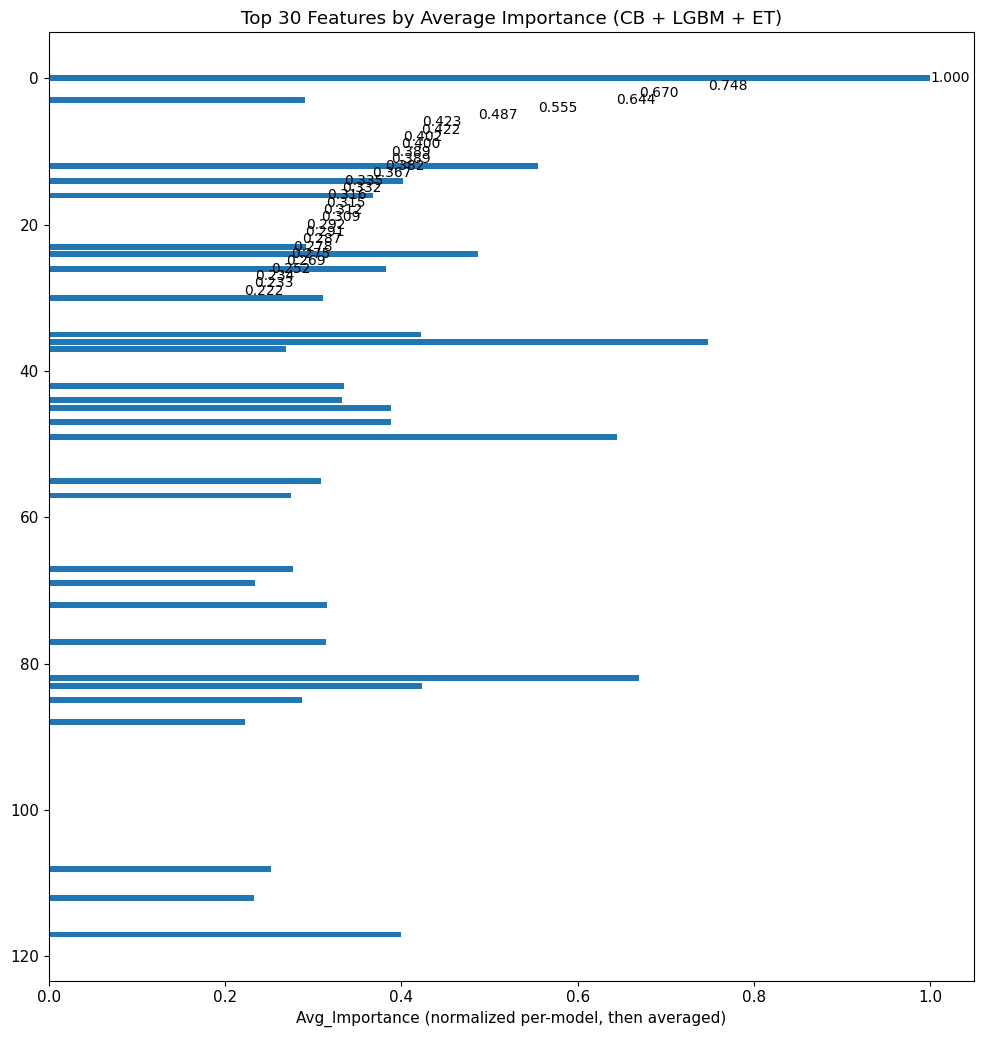

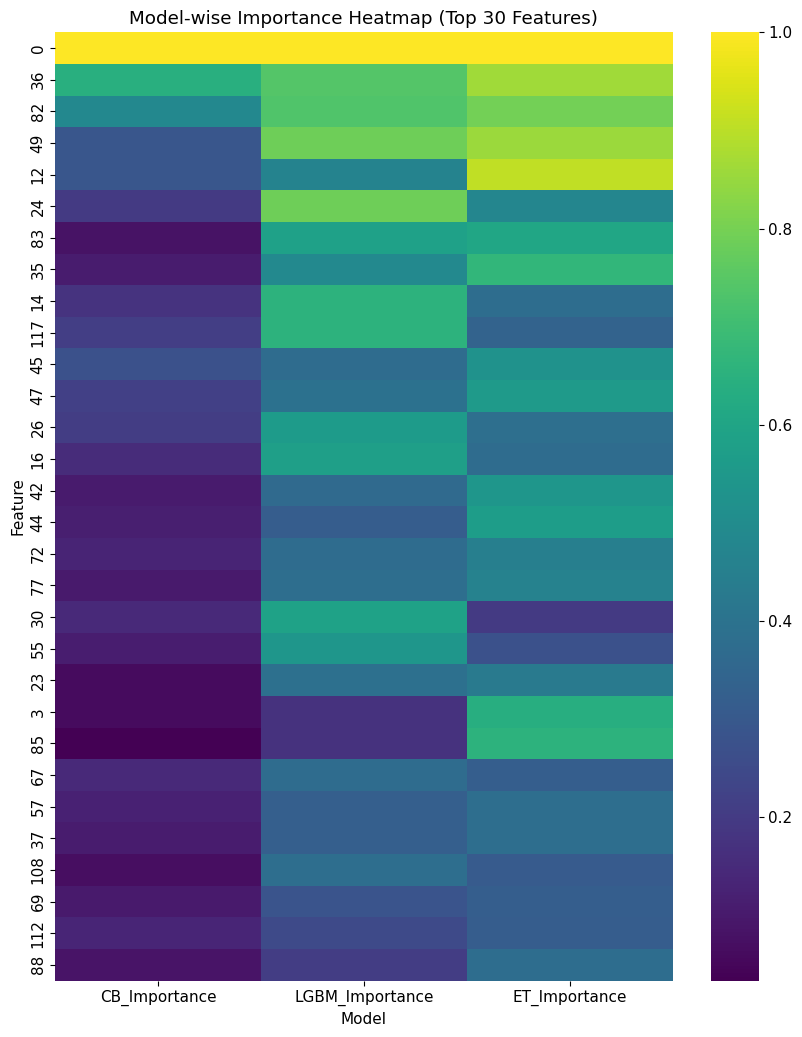

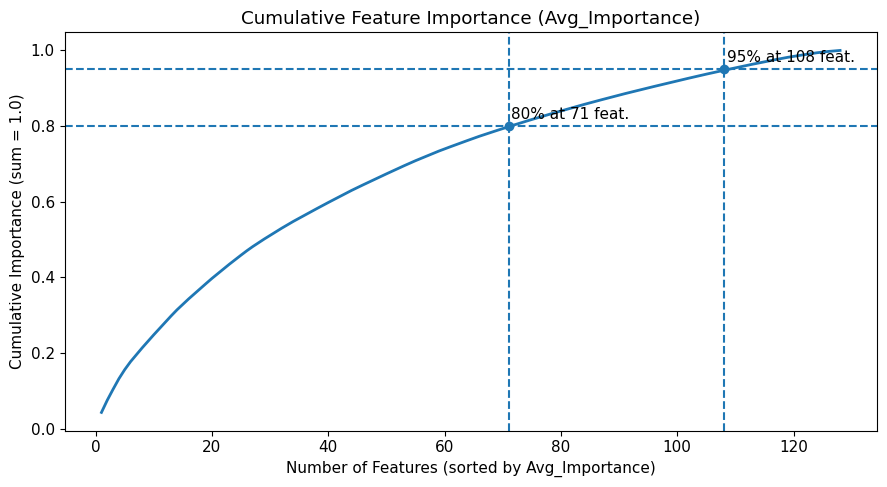

In [18]:
# === Feature-Importance Visualizations (drop-in cell) ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 0) Load the importance table (use in-memory if present; otherwise from CSV saved earlier)
try:
    imp = importance_df.copy()
except NameError:
    imp = pd.read_csv("feature_importance_basic.csv")

# Sort by averaged importance (desc)
imp = imp.sort_values('Avg_Importance', ascending=False).reset_index(drop=True)

# ---------- Config ----------
top_n = 30  # change to see more/less features in the plots
font_size = 11
plt.rcParams.update({"font.size": font_size})

# 1) Horizontal bar chart of top-N features by Avg_Importance
top_imp = imp.head(top_n).copy()

plt.figure(figsize=(10, max(6, 0.35*len(top_imp))))
plt.barh(top_imp['Feature'], top_imp['Avg_Importance'])
plt.gca().invert_yaxis()  # show most important at top
plt.xlabel("Avg_Importance (normalized per-model, then averaged)")
plt.title(f"Top {top_n} Features by Average Importance (CB + LGBM + ET)")
# Optional: annotate bars
for i, v in enumerate(top_imp['Avg_Importance']):
    plt.text(v, i, f"{v:.3f}", va='center', ha='left', fontsize=font_size-1)
plt.tight_layout()
plt.show()

# 2) Heatmap comparing model-wise importances for the same top-N features
heat = top_imp[['Feature', 'CB_Importance', 'LGBM_Importance', 'ET_Importance']].set_index('Feature')
plt.figure(figsize=(8.5, max(6, 0.35*len(heat))))
sns.heatmap(heat, annot=False, cmap="viridis")
plt.title(f"Model-wise Importance Heatmap (Top {top_n} Features)")
plt.xlabel("Model")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# 3) Cumulative importance curve (using normalized Avg_Importance that sums to 1)
curve = imp.copy()
curve['NormAvg'] = curve['Avg_Importance'] / curve['Avg_Importance'].sum()
curve['CumNormAvg'] = curve['NormAvg'].cumsum()

k80 = int((curve['CumNormAvg'] <= 0.80).sum())
k95 = int((curve['CumNormAvg'] <= 0.95).sum())

plt.figure(figsize=(9, 5))
plt.plot(range(1, len(curve)+1), curve['CumNormAvg'], linewidth=2)
plt.axhline(0.80, linestyle='--')
plt.axhline(0.95, linestyle='--')
plt.axvline(k80, linestyle='--')
plt.axvline(k95, linestyle='--')
plt.scatter([k80, k95], [0.80, 0.95])

plt.title("Cumulative Feature Importance (Avg_Importance)")
plt.xlabel("Number of Features (sorted by Avg_Importance)")
plt.ylabel("Cumulative Importance (sum = 1.0)")
plt.text(k80+0.5, 0.80+0.02, f"80% at {k80} feat.", fontsize=font_size)
plt.text(k95+0.5, 0.95+0.02, f"95% at {k95} feat.", fontsize=font_size)
plt.tight_layout()
plt.show()

# ---------- (Optional) Save figures ----------
# plt.savefig("feat_imp_top_bar.png", dpi=200, bbox_inches="tight")
# plt.savefig("feat_imp_heatmap.png", dpi=200, bbox_inches="tight")
# plt.savefig("feat_imp_cum_curve.png", dpi=200, bbox_inches="tight")


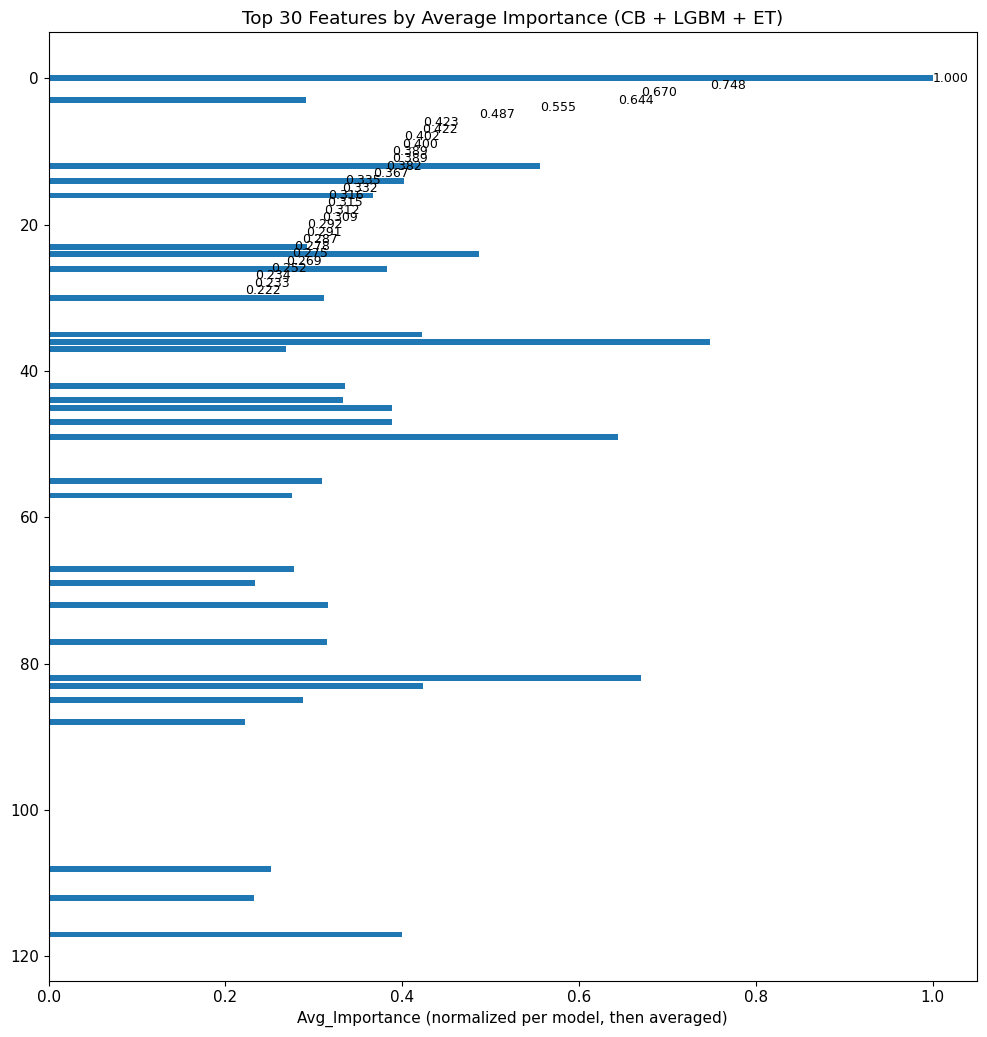

In [19]:
# --- Bar Chart: Top-N by Avg_Importance from importance_df ---
import pandas as pd
import matplotlib.pyplot as plt

try:
    imp = importance_df.copy()
except NameError:
    imp = pd.read_csv("feature_importance_basic.csv")

imp = imp.sort_values("Avg_Importance", ascending=False).reset_index(drop=True)
top_n = 30  # tweak as needed
top_imp = imp.head(top_n)

plt.figure(figsize=(10, max(6, 0.35*len(top_imp))))
plt.barh(top_imp["Feature"], top_imp["Avg_Importance"])
plt.gca().invert_yaxis()
plt.xlabel("Avg_Importance (normalized per model, then averaged)")
plt.title(f"Top {top_n} Features by Average Importance (CB + LGBM + ET)")
for i, v in enumerate(top_imp["Avg_Importance"]):
    plt.text(v, i, f"{v:.3f}", va="center", ha="left", fontsize=9)
plt.tight_layout()
plt.show()


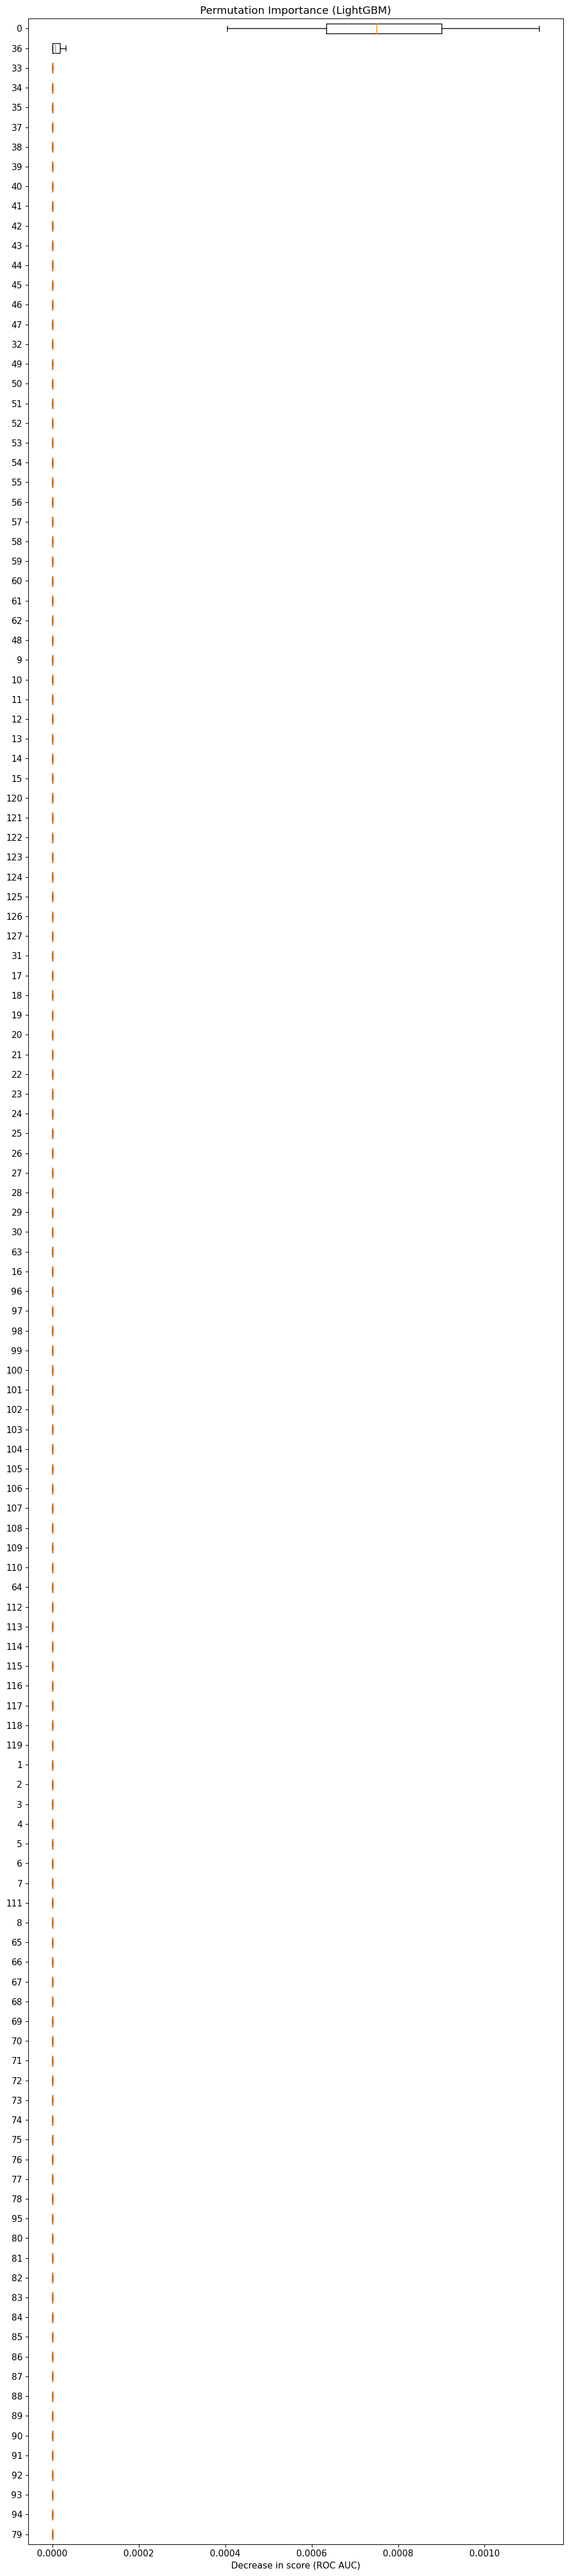

In [20]:
# --- Permutation Importance (using LightGBM model `lgbm`) ---
import numpy as np
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance

# Prefer held-out test if available; else fallback to all data
try:
    X_eval, y_eval = X_test, y_test
except NameError:
    X_eval, y_eval = X.values, y.values

# Make sure we have feature names
try:
    feature_names = dataf.columns[:-1]
except:
    feature_names = np.arange(X_eval.shape[1]).astype(str)

# Run permutation importance
result = permutation_importance(
    lgbm, X_eval, y_eval,
    n_repeats=10,
    random_state=42,
    scoring="roc_auc"  # for binary classification; switch to "accuracy" if you prefer
)

sorted_idx = np.argsort(result.importances_mean)
labels = np.array(feature_names)[sorted_idx]

plt.figure(figsize=(10, max(6, 0.35*len(labels))))
plt.boxplot(result.importances[sorted_idx].T, vert=False, labels=labels)
plt.title("Permutation Importance (LightGBM)")
plt.xlabel("Decrease in score (ROC AUC)")
plt.tight_layout()
plt.show()


LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray


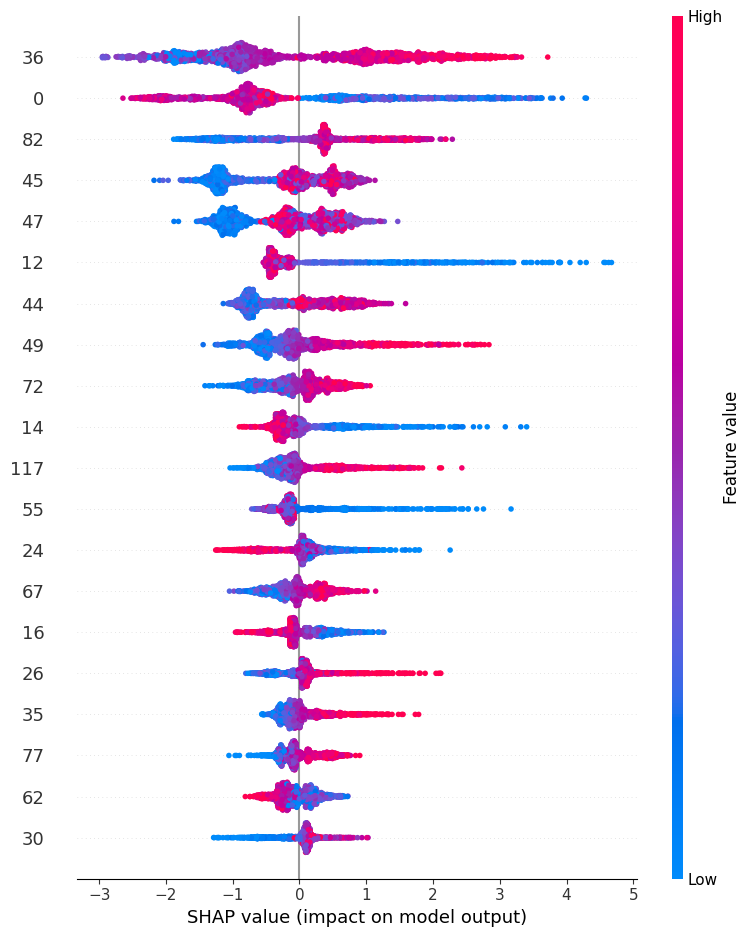

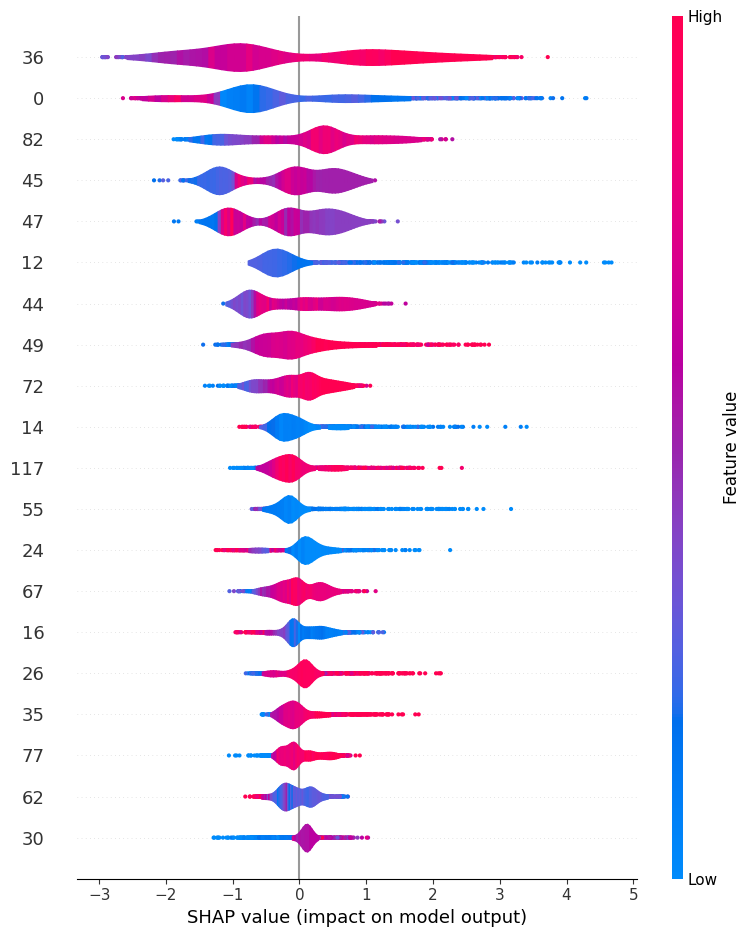

In [21]:
# --- SHAP Summary / Beeswarm (using LightGBM `lgbm`) ---
import numpy as np
import pandas as pd

# Install shap if missing (Kaggle usually has it)
try:
    import shap
except ImportError:
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "shap"])
    import shap

# Prepare a manageable sample for speed (optional)
try:
    X_full = dataf.iloc[:, :-1]
except:
    # If you don't have the DataFrame, wrap numpy with a DataFrame
    X_full = pd.DataFrame(X, columns=feature_names)

sample_n = min(2000, len(X_full))  # adjust as needed
X_sample = X_full.sample(sample_n, random_state=42) if len(X_full) > sample_n else X_full

# SHAP values (TreeExplainer works well for LGBM)
explainer = shap.TreeExplainer(lgbm)
shap_values = explainer.shap_values(X_sample)

# Handle binary vs. multi-class
if isinstance(shap_values, list):
    shap_vals_to_plot = shap_values[1]  # class 1 for binary classification
else:
    shap_vals_to_plot = shap_values

# 3a) SHAP summary (dot / beeswarm)
shap.summary_plot(shap_vals_to_plot, X_sample, show=True)

# 3b) SHAP violin-style beeswarm (optional alternative)
shap.summary_plot(shap_vals_to_plot, X_sample, plot_type="violin", show=True)


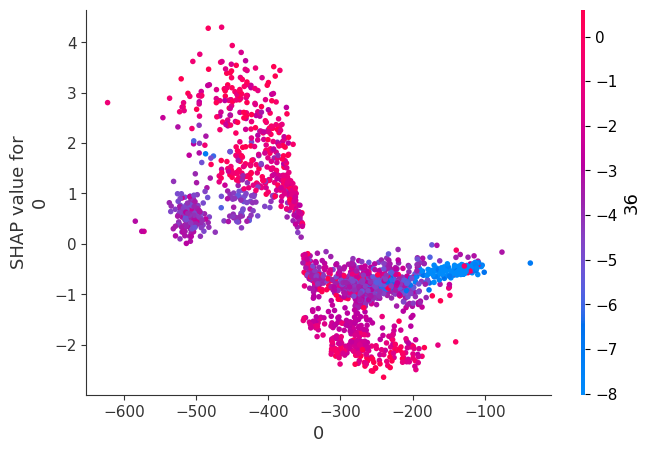

In [22]:
# --- SHAP Dependence Plot for a specific (top) feature ---
# Pick top feature from your averaged ranking
try:
    imp_sorted = importance_df.sort_values("Avg_Importance", ascending=False).reset_index(drop=True)
except NameError:
    imp_sorted = pd.read_csv("feature_importance_basic.csv").sort_values("Avg_Importance", ascending=False).reset_index(drop=True)

top_feature = imp_sorted.loc[0, "Feature"]  # change to any feature name you want

# Dependence plot (will also show interaction hints)
shap.dependence_plot(top_feature, shap_vals_to_plot, X_sample, show=True)


Top-K chosen for visualization: K=71


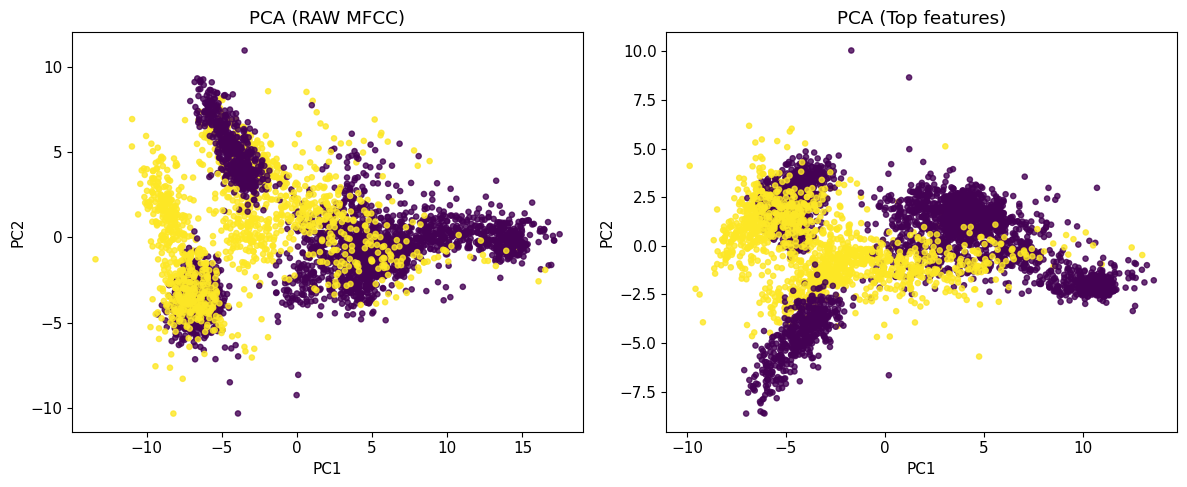

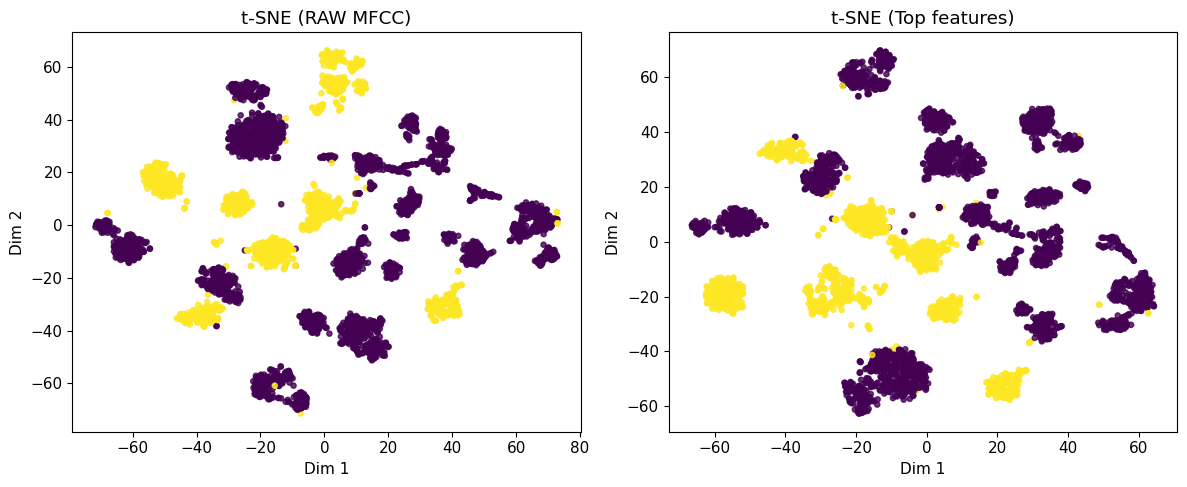

In [23]:
# ===========================
# Visual differences: RAW MFCC vs Importance-based MFCC
# ===========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# 0) Prepare data with names intact
X_full = dataf.iloc[:, :-1]
y_full = dataf.iloc[:, -1].astype(int)

# 1) Build top-K feature list (80% cumulative importance; min 10)
imp_sorted = importance_df.sort_values("Avg_Importance", ascending=False).reset_index(drop=True)
imp_sorted["NormAvg"] = imp_sorted["Avg_Importance"] / imp_sorted["Avg_Importance"].sum()
imp_sorted["CumNormAvg"] = imp_sorted["NormAvg"].cumsum()
k80 = int((imp_sorted["CumNormAvg"] <= 0.80).sum())
topK = max(k80, 10)

all_features = list(X_full.columns)

def coerce_to_names(feat_list, all_names):
    if len(feat_list) and np.issubdtype(np.array(feat_list).dtype, np.integer):
        mapped = [all_names[i] for i in feat_list if 0 <= i < len(all_names)]
    else:
        mapped = [f for f in feat_list if f in set(all_names)]
    seen, out = set(), []
    for f in mapped:
        if f not in seen:
            seen.add(f); out.append(f)
    return out

raw_topK = imp_sorted.loc[:topK-1, "Feature"].tolist()
topK_features = coerce_to_names(raw_topK, all_features)

print(f"Top-K chosen for visualization: K={len(topK_features)}")

X_raw = X_full.values
X_top = X_full[topK_features].values
classes = y_full.values

# Standardize each view (important for PCA/t-SNE)
Xs_raw = StandardScaler().fit_transform(X_raw)
Xs_top = StandardScaler().fit_transform(X_top)

# -------------------------
# A) PCA 2D scatter: RAW vs TOP-K
# -------------------------
pca_raw = PCA(n_components=2, random_state=42).fit_transform(Xs_raw)
pca_top = PCA(n_components=2, random_state=42).fit_transform(Xs_top)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(pca_raw[:,0], pca_raw[:,1], c=classes, cmap="viridis", s=14, alpha=0.8)
plt.title("PCA (RAW MFCC)")
plt.xlabel("PC1"); plt.ylabel("PC2")

plt.subplot(1,2,2)
plt.scatter(pca_top[:,0], pca_top[:,1], c=classes, cmap="viridis", s=14, alpha=0.8)
plt.title(f"PCA (Top features)")
plt.xlabel("PC1"); plt.ylabel("PC2")

plt.tight_layout()
plt.show()

# -------------------------
# B) t-SNE 2D scatter: RAW vs TOP-K
# -------------------------
tsne_raw = TSNE(n_components=2, learning_rate="auto", init="pca", perplexity=30, random_state=42).fit_transform(Xs_raw)
tsne_top = TSNE(n_components=2, learning_rate="auto", init="pca", perplexity=30, random_state=42).fit_transform(Xs_top)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(tsne_raw[:,0], tsne_raw[:,1], c=classes, cmap="viridis", s=14, alpha=0.8)
plt.title("t-SNE (RAW MFCC)")
plt.xlabel("Dim 1"); plt.ylabel("Dim 2")

plt.subplot(1,2,2)
plt.scatter(tsne_top[:,0], tsne_top[:,1], c=classes, cmap="viridis", s=14, alpha=0.8)
plt.title(f"t-SNE (Top features)")
plt.xlabel("Dim 1"); plt.ylabel("Dim 2")

plt.tight_layout()
plt.show()

# -------------------------
# C) Correlation heatmaps: RAW vs TOP-K
#     (structure differences—dense vs focused correlations)
# -------------------------
# For RAW, use a random subset of features if too large (to keep heatmap readable)
max_raw_heat = min(40, X_full.shape[1])   # show up_


Top-K chosen for visuals: K=71


invalid value encountered in less
invalid value encountered in less


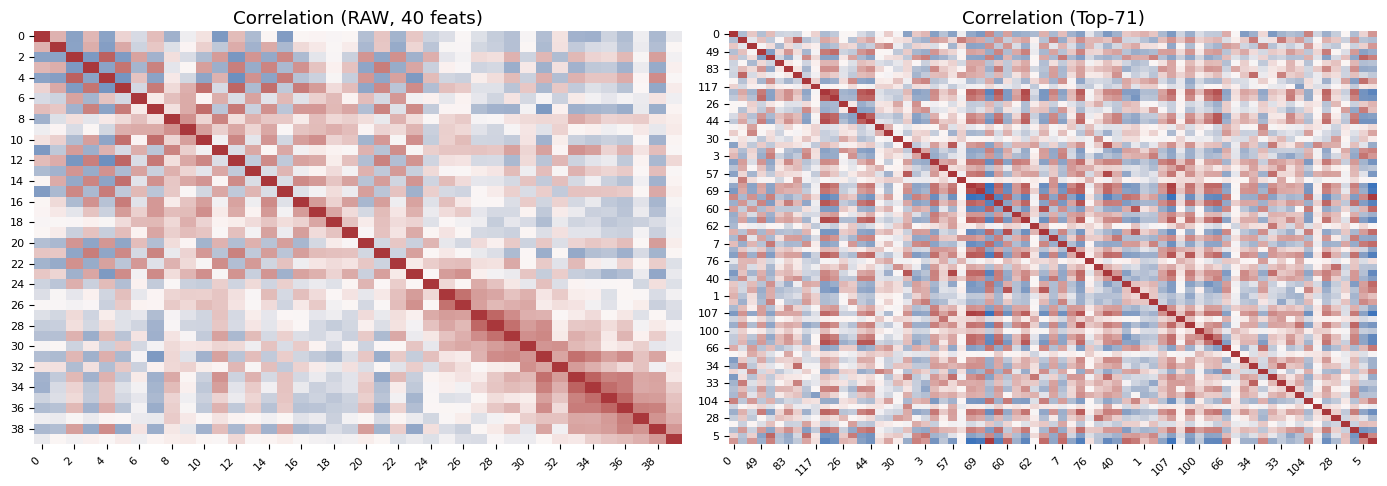

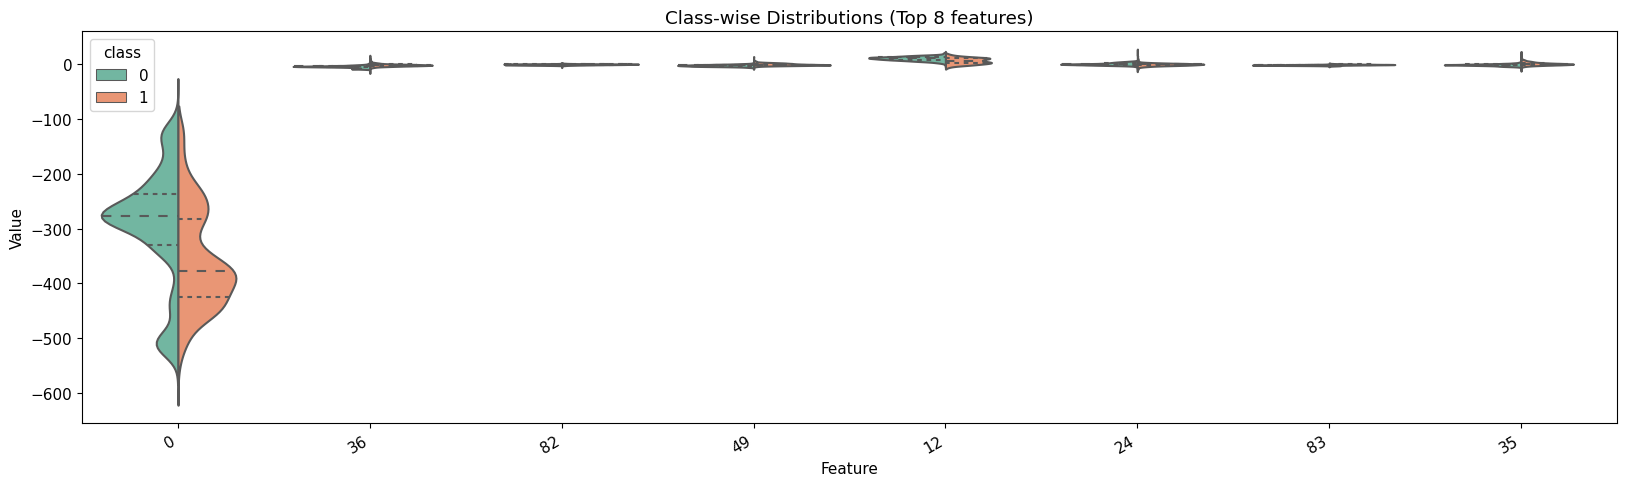

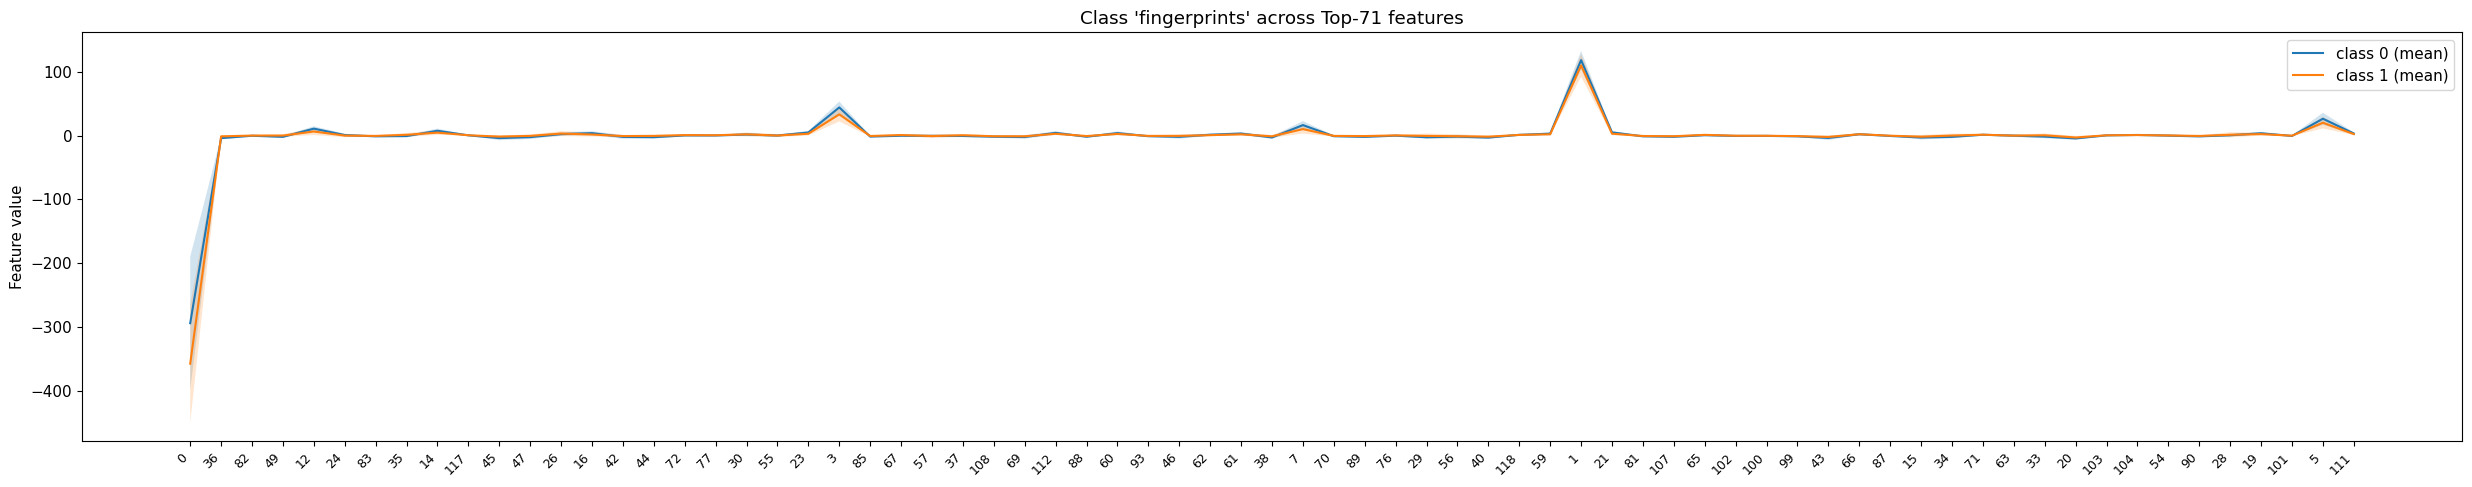

In [24]:
# ===========================
# Correlation heatmaps • Violin plots • Class "fingerprint"
# (RAW MFCC vs. Importance-based Top-K)
# ===========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Inputs expected to exist:
# dataf           -> your full dataframe with last column 'class'
# importance_df   -> columns: Feature, CB_Importance, LGBM_Importance, ET_Importance, Avg_Importance

# ---- Config ----
RAW_HEAT_N = 40      # how many RAW features to show in the correlation heatmap (for readability)
TOPK_MIN   = 10      # minimum Top-K features to use
VIOLIN_N   = 8       # how many top features to show in violin plots

# ---- Prep data ----
X_full = dataf.iloc[:, :-1]
y_full = dataf.iloc[:, -1].astype(int)
all_features = list(X_full.columns)

# Map any integer feature indices -> names; keep only valid names
def coerce_to_names(feat_list, all_names):
    if len(feat_list) and np.issubdtype(np.array(feat_list).dtype, np.integer):
        mapped = [all_names[i] for i in feat_list if 0 <= i < len(all_names)]
    else:
        mapped = [f for f in feat_list if f in set(all_names)]
    # de-dupe, preserve order
    seen, out = set(), []
    for f in mapped:
        if f not in seen:
            seen.add(f); out.append(f)
    return out

# Rank by Avg_Importance and pick Top-K to cover ~80% cumulative (but at least TOPK_MIN)
imp_sorted = importance_df.sort_values("Avg_Importance", ascending=False).reset_index(drop=True)
imp_sorted["NormAvg"] = imp_sorted["Avg_Importance"] / imp_sorted["Avg_Importance"].sum()
imp_sorted["CumNormAvg"] = imp_sorted["NormAvg"].cumsum()
k80 = int((imp_sorted["CumNormAvg"] <= 0.80).sum())
topK = max(k80, TOPK_MIN)

raw_topK = imp_sorted.loc[:topK-1, "Feature"].tolist()
topK_features = coerce_to_names(raw_topK, all_features)

print(f"Top-K chosen for visuals: K={len(topK_features)}")

# ===========================
# A) Correlation heatmaps
# ===========================
# RAW subset for readability
raw_subset = all_features[:min(RAW_HEAT_N, len(all_features))]
corr_raw = X_full[raw_subset].corr()
corr_top = X_full[topK_features].corr()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(corr_raw, ax=axes[0], cmap="vlag", center=0, cbar=False)
axes[0].set_title(f"Correlation (RAW, {len(raw_subset)} feats)")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha="right", fontsize=8)
axes[0].set_yticklabels(axes[0].get_yticklabels(), rotation=0, fontsize=8)

sns.heatmap(corr_top, ax=axes[1], cmap="vlag", center=0, cbar=False)
axes[1].set_title(f"Correlation (Top-{len(topK_features)})")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha="right", fontsize=8)
axes[1].set_yticklabels(axes[1].get_yticklabels(), rotation=0, fontsize=8)

plt.tight_layout()
plt.show()

# ===========================
# B) Class-wise violin plots (Top features)
# ===========================
top_show = min(VIOLIN_N, len(topK_features))
violin_cols = topK_features[:top_show]

long_df = pd.melt(
    pd.concat([X_full[violin_cols], y_full.rename("class")], axis=1),
    id_vars="class", value_vars=violin_cols,
    var_name="Feature", value_name="Value"
)

plt.figure(figsize=(1.8*top_show + 2, 5))
sns.violinplot(
    data=long_df, x="Feature", y="Value",
    hue="class", split=True, inner="quart", palette="Set2", cut=0
)
plt.title(f"Class-wise Distributions (Top {top_show} features)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# ===========================
# C) Class "fingerprint" (mean ± std across Top-K)
# ===========================
means_0 = X_full.loc[y_full == 0, topK_features].mean()
stds_0  = X_full.loc[y_full == 0, topK_features].std()
means_1 = X_full.loc[y_full == 1, topK_features].mean()
stds_1  = X_full.loc[y_full == 1, topK_features].std()

idx = np.arange(len(topK_features))
plt.figure(figsize=(max(10, 0.35*len(topK_features)), 5))
plt.plot(idx, means_0.values, label="class 0 (mean)")
plt.fill_between(idx, (means_0 - stds_0).values, (means_0 + stds_0).values, alpha=0.2)
plt.plot(idx, means_1.values, label="class 1 (mean)")
plt.fill_between(idx, (means_1 - stds_1).values, (means_1 + stds_1).values, alpha=0.2)
plt.xticks(idx, topK_features, rotation=45, ha="right", fontsize=9)
plt.ylabel("Feature value")
plt.title(f"Class 'fingerprints' across Top-{len(topK_features)} features")
plt.legend()
plt.tight_layout()
plt.show()


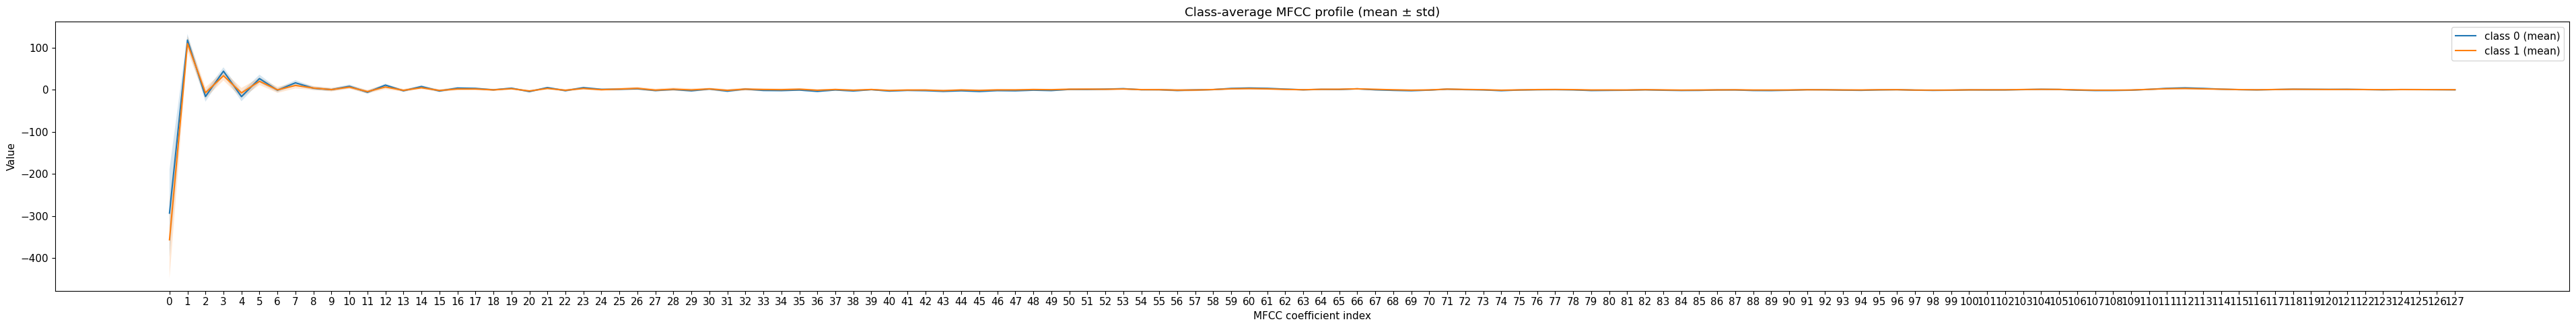

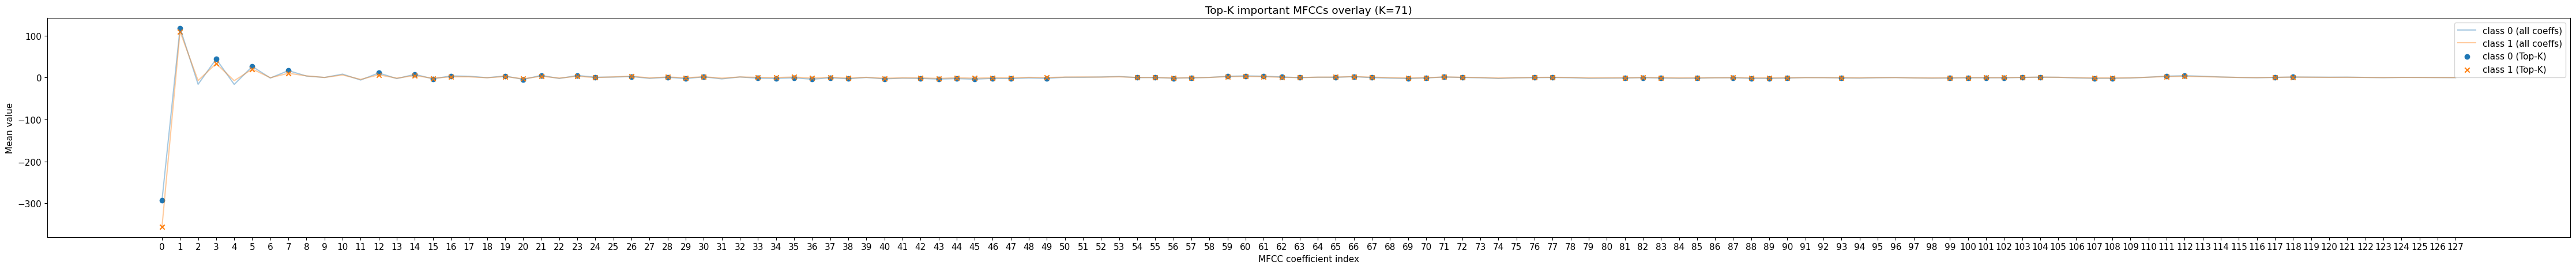

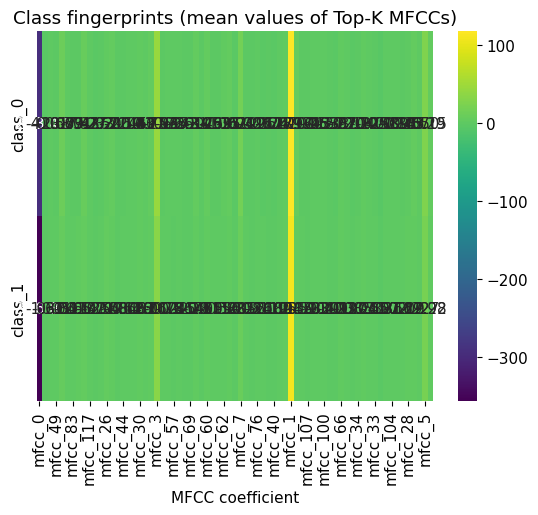

In [30]:
# ===========================
# MFCC plotting (numeric column names: 1,2,3,...)
# ===========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = dataf.copy()
y = df['class'].astype(int)
X = df.drop(columns=['class'])

# Detect MFCC columns (assume all except 'class' are MFCCs)
mfcc_cols = X.columns.tolist()
coeff_list = [int(c) for c in mfcc_cols]  # use numeric column names as coeff index
mfcc_vec = X.copy()
mfcc_vec.columns = [f"mfcc_{c}" for c in coeff_list]

# --- Class-average MFCC profile (mean ± std) ---
m0 = mfcc_vec[y==0].mean()
s0 = mfcc_vec[y==0].std()
m1 = mfcc_vec[y==1].mean()
s1 = mfcc_vec[y==1].std()

idx = np.arange(len(coeff_list))
plt.figure(figsize=(max(8, 0.3*len(coeff_list)), 5))
plt.plot(idx, m0.values, label="class 0 (mean)")
plt.fill_between(idx, (m0-s0).values, (m0+s0).values, alpha=0.18)
plt.plot(idx, m1.values, label="class 1 (mean)")
plt.fill_between(idx, (m1-s1).values, (m1+s1).values, alpha=0.18)
plt.xticks(idx, coeff_list, rotation=0)
plt.xlabel("MFCC coefficient index")
plt.ylabel("Value")
plt.title("Class-average MFCC profile (mean ± std)")
plt.legend()
plt.tight_layout()
plt.show()

# --- Overlay Top-K important MFCCs on means ---
imp_sorted = importance_df.sort_values("Avg_Importance", ascending=False).reset_index(drop=True)
# Keep only rows whose Feature is in your numeric column names
imp_mfcc = imp_sorted[imp_sorted["Feature"].astype(str).isin([str(c) for c in coeff_list])]
imp_mfcc = imp_mfcc.copy()
imp_mfcc["coeff"] = imp_mfcc["Feature"].astype(int)
imp_mfcc = imp_mfcc.drop_duplicates(subset=["coeff"])
imp_mfcc["Norm"] = imp_mfcc["Avg_Importance"]/imp_mfcc["Avg_Importance"].sum()
imp_mfcc = imp_mfcc.sort_values("Avg_Importance", ascending=False)
imp_mfcc["Cum"] = imp_mfcc["Norm"].cumsum()
K = max(10, int((imp_mfcc["Cum"]<=0.80).sum())) if not imp_mfcc.empty else 13
top_coeffs = imp_mfcc.head(K)["coeff"].tolist()

m0_top = mfcc_vec.loc[y==0, [f"mfcc_{c}" for c in top_coeffs]].mean()
m1_top = mfcc_vec.loc[y==1, [f"mfcc_{c}" for c in top_coeffs]].mean()

plt.figure(figsize=(max(8, 0.35*len(coeff_list)), 4.8))
plt.plot(idx, m0.values, alpha=0.4, label="class 0 (all coeffs)")
plt.plot(idx, m1.values, alpha=0.4, label="class 1 (all coeffs)")
top_idx = [coeff_list.index(c) for c in top_coeffs]
plt.scatter(top_idx, m0_top.values, label="class 0 (Top-K)", marker='o')
plt.scatter(top_idx, m1_top.values, label="class 1 (Top-K)", marker='x')
plt.xticks(idx, coeff_list)
plt.xlabel("MFCC coefficient index")
plt.ylabel("Mean value")
plt.title(f"Top-K important MFCCs overlay (K={len(top_coeffs)})")
plt.legend()
plt.tight_layout()
plt.show()

# --- Class "fingerprint" heatmap for Top-K ---
means_0 = mfcc_vec.loc[y==0, [f"mfcc_{c}" for c in top_coeffs]].mean()
means_1 = mfcc_vec.loc[y==1, [f"mfcc_{c}" for c in top_coeffs]].mean()

finger_df = pd.DataFrame({"class_0": means_0, "class_1": means_1})
sns.heatmap(finger_df.T, cmap="viridis", annot=True, fmt=".2f")
plt.title("Class fingerprints (mean values of Top-K MFCCs)")
plt.xlabel("MFCC coefficient")
plt.show()


Mean spectrograms skipped (no time axis inferred).


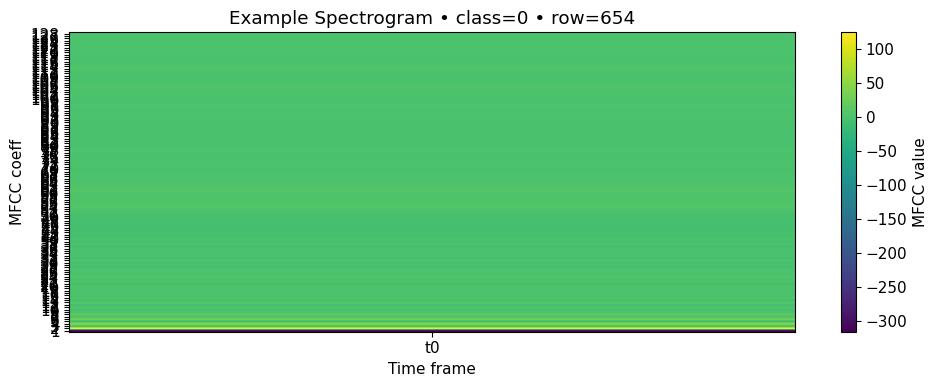

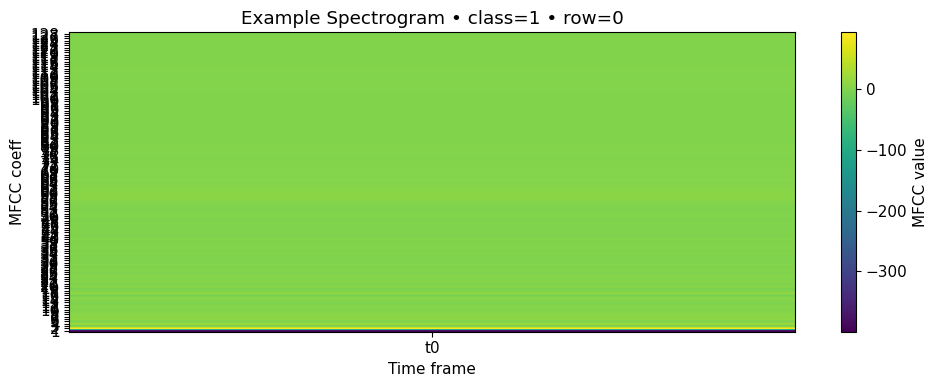

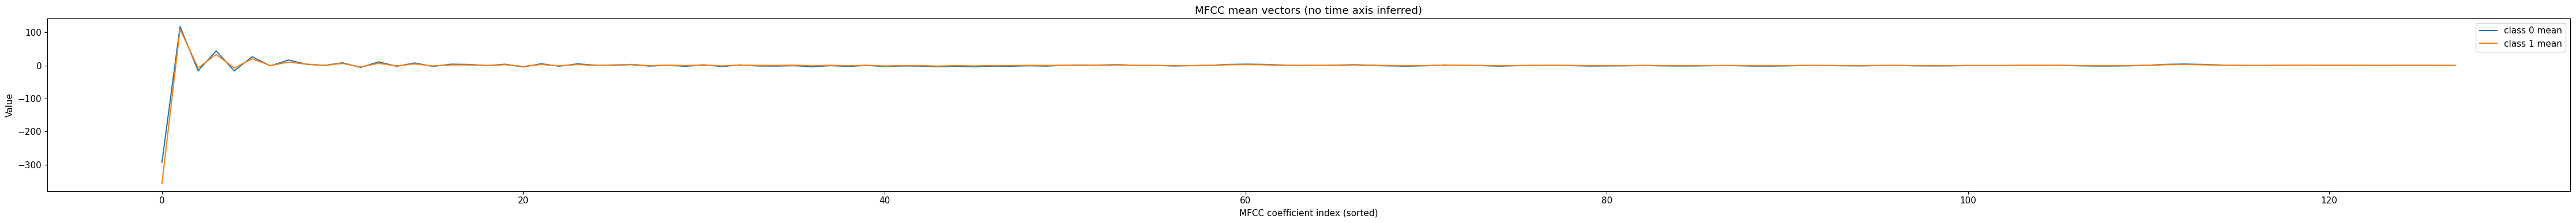

In [31]:
# ===========================
# MFCC spectrogram plots from CSV (robust to flat/time-sliced schemas)
# ===========================
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Load (safe re-load) ---
try:
    df = dataf.copy()
except NameError:
    df = pd.read_csv("/kaggle/input/mfcc-of-slurred-vocal/MFCCoutput.csv")

# Drop obvious index col if present
if df.columns[0].lower() in {"", "unnamed: 0", "index"} or not df.columns[0]:
    df = df.drop(columns=df.columns[0])

# Ensure binary class as int (0/1)
if "class" not in df.columns:
    raise ValueError("No 'class' column found in CSV.")
df.loc[df["class"].isin(["non_dysarthria", "dysarthria"]), "class"] = (
    df["class"].map({"non_dysarthria": 0.0, "dysarthria": 1.0})
)
df["class"] = df["class"].astype(int)

# Feature columns
X = df.drop(columns=["class"])
y = df["class"].astype(int)

# ---------------------------------------------
# 1) Detect schema
#    A) Time-sliced headers like '1_t0' or 'mfcc_1_t35'
#    B) Flat numeric headers like '1','2',... possibly flattened over time
# ---------------------------------------------
cols = list(X.columns)

def parse_coeff_time(col):
    s = str(col)
    m = re.match(r'(?i)^(?:mfcc[_\-]?)?(\d+)[_\-]?t(\d+)$', s)  # e.g., mfcc_1_t0 or 1_t0
    if m:
        return int(m.group(1)), int(m.group(2))
    return None, None

parsed = [parse_coeff_time(c) for c in cols]
has_time_headers = any(t is not None for _, t in parsed)

# ---------------------------------------------
# 2) Build mapping coeff×time -> column (either from headers or by reshape guess)
# ---------------------------------------------
if has_time_headers:
    # Build tidy map from explicit coeff/time naming
    parsed_df = pd.DataFrame(
        {"col": cols, "coeff": [p[0] for p in parsed], "time": [p[1] for p in parsed]}
    ).dropna()
    coeffs = sorted(parsed_df["coeff"].unique())
    times  = sorted(parsed_df["time"].unique())
    lut = parsed_df.set_index(["coeff", "time"])["col"].to_dict()

    def row_to_matrix(row):
        M = np.zeros((len(coeffs), len(times)), dtype=float)
        for i, c in enumerate(coeffs):
            for j, t in enumerate(times):
                col = lut.get((c, t))
                M[i, j] = row[col]
        return M, coeffs, times

else:
    # No time in headers. Try to infer n_mfcc so we can reshape [n_mfcc x n_frames]
    # Typical MFCC counts to try:
    candidates = [13, 20, 40]
    n_feats = len(cols)
    numeric_sorted_cols = sorted(cols, key=lambda x: int(str(x)))  # order by number if columns are '1','2',...
    chosen = None
    for k in candidates:
        if n_feats % k == 0:
            chosen = k
            break
    if chosen is None:
        # If nothing fits, we cannot form a spectrogram; treat as single vector
        chosen = n_feats  # -> one "time frame"

    n_mfcc = chosen
    n_frames = n_feats // n_mfcc
    coeffs = list(range(1, n_mfcc + 1))
    times  = list(range(n_frames))

    def row_to_matrix(row):
        # Take values in numeric column order, then reshape (row-major)
        v = row[numeric_sorted_cols].values.astype(float)
        M = v.reshape(n_mfcc, n_frames, order="C")  # coeff along rows, time along cols
        return M, coeffs, times

# ---------------------------------------------
# 3) Plot helpers
# ---------------------------------------------
def plot_spectrogram(M, coeffs, times, title="MFCC Spectrogram"):
    plt.figure(figsize=(10, 4))
    im = plt.imshow(M, aspect="auto", origin="lower")
    plt.colorbar(im, label="MFCC value")
    plt.yticks(range(len(coeffs)), coeffs)
    # x ticks: keep it readable
    if len(times) > 1:
        xt = np.linspace(0, len(times)-1, min(10, len(times))).astype(int)
        plt.xticks(xt, [times[t] for t in xt])
        plt.xlabel("Time frame")
    else:
        plt.xticks([0], ["t0"])
        plt.xlabel("Time frame")
    plt.ylabel("MFCC coeff")
    plt.title(title)
    plt.tight_layout()
    plt.show()

# ---------------------------------------------
# 4) Per-class mean spectrograms (if multiple frames exist)
# ---------------------------------------------
# Build mean matrix per class by averaging sample matrices
def class_mean_matrix(cls):
    idxs = df.index[y == cls].tolist()
    if not idxs:
        return None
    mats = []
    for rid in idxs:
        M, _, _ = row_to_matrix(X.loc[rid])
        mats.append(M)
    return np.nanmean(np.stack(mats, axis=0), axis=0)

M0 = class_mean_matrix(0)
M1 = class_mean_matrix(1)

if M0 is not None and M1 is not None and M0.shape[1] > 1:
    plot_spectrogram(M0, coeffs, times, title="Class 0 • Mean MFCC Spectrogram")
    plot_spectrogram(M1, coeffs, times, title="Class 1 • Mean MFCC Spectrogram")
else:
    print("Mean spectrograms skipped (no time axis inferred).")

# ---------------------------------------------
# 5) One example per class (spectrograms)
# ---------------------------------------------
examples = []
for cls in sorted(y.unique()):
    ids = df.index[y == cls].tolist()
    if ids:
        examples.append((ids[0], cls))

for rid, cls in examples:
    M, _, _ = row_to_matrix(X.loc[rid])
    title = f"Example Spectrogram • class={cls} • row={rid}"
    plot_spectrogram(M, coeffs, times, title=title)

# ---------------------------------------------
# 6) Fallback: if no time axis (n_frames == 1), show MFCC line profiles
# ---------------------------------------------
if len(times) == 1:
    # Build per-class mean vectors
    vec0 = X.loc[y==0].mean().values
    vec1 = X.loc[y==1].mean().values
    # If we couldn't reshape, just plot as a single vector across sorted columns
    idx = np.arange(len(vec0))
    plt.figure(figsize=(max(8, 0.35*len(vec0)), 4))
    plt.plot(idx, vec0, label="class 0 mean")
    plt.plot(idx, vec1, label="class 1 mean")
    plt.title("MFCC mean vectors (no time axis inferred)")
    plt.xlabel("MFCC coefficient index (sorted)")
    plt.ylabel("Value")
    plt.legend()
    plt.tight_layout()
    plt.show()


Detected schema -> coeffs: 16, frames: 8


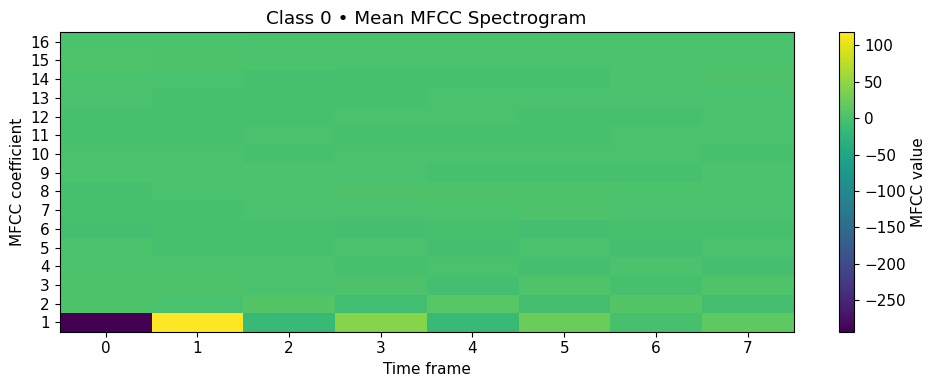

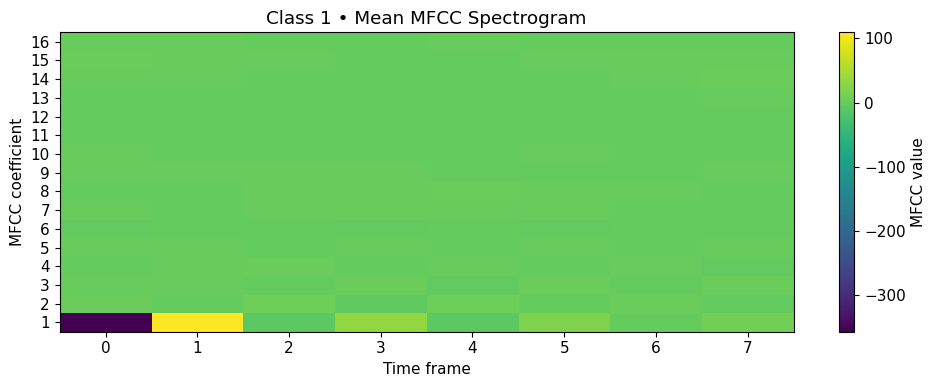

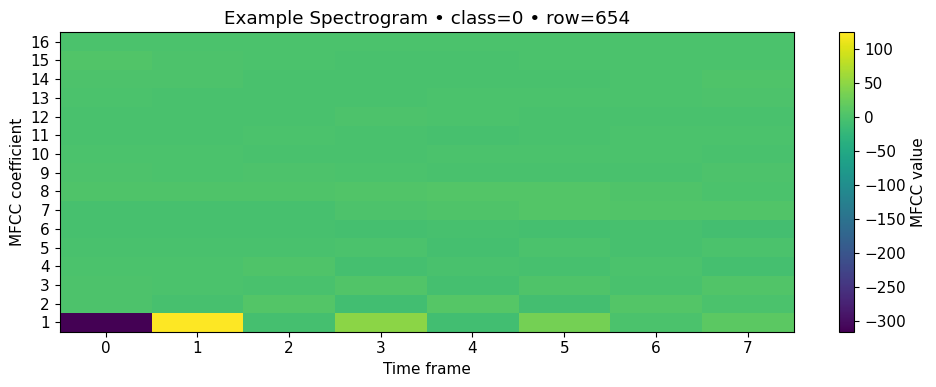

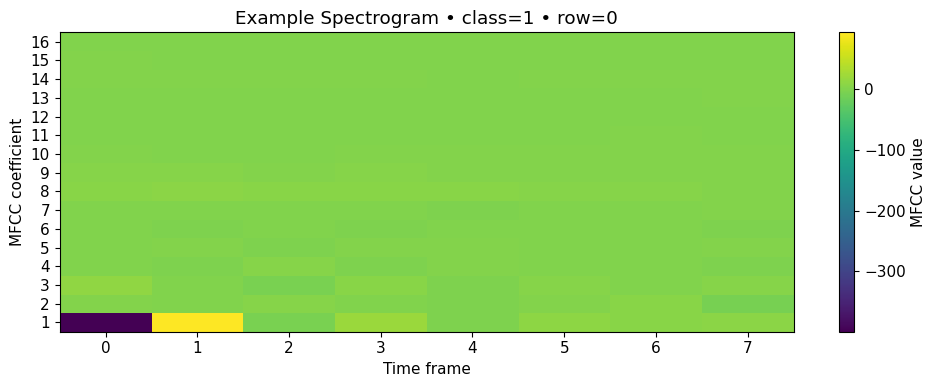

In [32]:
# MFCC spectrograms from CSV: handles time-sliced (e.g., 1_t0) or flattened MFCC×time grids.
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CSV_PATH = "/kaggle/input/mfcc-of-slurred-vocal/MFCCoutput.csv"

# ---------- Load & clean ----------
df = pd.read_csv(CSV_PATH)
# drop obvious index column if present
first_col = str(df.columns[0]).lower()
if first_col in {"unnamed: 0", "index", ""}:
    df = df.drop(columns=[df.columns[0]])

if "class" not in df.columns:
    raise ValueError("The CSV must contain a 'class' column.")

# Map string labels if needed
df.loc[df["class"].isin(["non_dysarthria","dysarthria"]), "class"] = (
    df["class"].map({"non_dysarthria":0, "dysarthria":1})
)
df["class"] = df["class"].astype(int)

X = df.drop(columns=["class"])
y = df["class"].astype(int)

# ---------- Detect schema ----------
cols = list(X.columns)

def parse_coeff_time(col):
    s = str(col)
    m = re.match(r'(?i)^(?:mfcc[_\-]?)?(\d+)[_\-]?t(\d+)$', s)  # matches 1_t0, mfcc_1_t0, MFCC-2_t15
    if m:
        return int(m.group(1)), int(m.group(2))
    return None, None

parsed = [parse_coeff_time(c) for c in cols]
has_time_headers = any(t is not None for _, t in parsed)

# ---------- Build row -> matrix (coeff × time) ----------
if has_time_headers:
    parsed_df = pd.DataFrame({"col":cols,
                              "coeff":[p[0] for p in parsed],
                              "time":[p[1] for p in parsed]}).dropna()
    coeffs = sorted(parsed_df["coeff"].unique())
    times  = sorted(parsed_df["time"].unique())
    lut = parsed_df.set_index(["coeff","time"])["col"].to_dict()

    def row_to_matrix(row):
        M = np.zeros((len(coeffs), len(times)), dtype=float)
        for i, c in enumerate(coeffs):
            for j, t in enumerate(times):
                M[i, j] = row[lut[(c, t)]]
        return M, coeffs, times

else:
    # Flattened grid: try to infer (n_mfcc, n_frames).
    n_feats = X.shape[1]

    # Preferred MFCC counts; fall back to any divisor in [12..40], else single-frame.
    preferred = [13, 20, 40]
    candidates = [k for k in preferred if n_feats % k == 0]
    if not candidates:
        # any divisor between 12 and 40
        divisors = [k for k in range(12, 41) if n_feats % k == 0]
        candidates = divisors if divisors else [n_feats]  # 1 frame fallback

    n_mfcc = candidates[0]
    n_frames = n_feats // n_mfcc
    coeffs = list(range(1, n_mfcc+1))
    times  = list(range(n_frames))

    # sort columns numerically if headers are numbers
    try:
        numeric_sorted_cols = sorted(cols, key=lambda c: int(str(c)))
    except:
        numeric_sorted_cols = cols  # keep order as-is

    def row_to_matrix(row):
        v = row[numeric_sorted_cols].to_numpy(dtype=float)
        M = v.reshape(n_mfcc, n_frames, order="C")
        return M, coeffs, times

print(f"Detected schema -> coeffs: {len(coeffs)}, frames: {len(times)}")

# ---------- Plot helper ----------
def plot_spectrogram(M, coeffs, times, title):
    plt.figure(figsize=(10, 4))
    im = plt.imshow(M, aspect="auto", origin="lower")
    plt.colorbar(im, label="MFCC value")
    plt.yticks(range(len(coeffs)), coeffs)
    if len(times) > 1:
        xt = np.linspace(0, len(times)-1, min(10, len(times))).astype(int)
        plt.xticks(xt, [times[t] for t in xt])
        plt.xlabel("Time frame")
    else:
        plt.xticks([0], ["t0"])
        plt.xlabel("Time frame")
    plt.ylabel("MFCC coefficient")
    plt.title(title)
    plt.tight_layout()
    plt.show()

# ---------- Class-mean spectrograms ----------
def class_mean_matrix(cls):
    ids = df.index[y == cls].tolist()
    if not ids:
        return None
    mats = []
    for rid in ids:
        M, _, _ = row_to_matrix(X.loc[rid])
        mats.append(M)
    return np.nanmean(np.stack(mats, axis=0), axis=0)

M0 = class_mean_matrix(0)
M1 = class_mean_matrix(1)

if M0 is not None and M1 is not None and len(times) > 1:
    plot_spectrogram(M0, coeffs, times, "Class 0 • Mean MFCC Spectrogram")
    plot_spectrogram(M1, coeffs, times, "Class 1 • Mean MFCC Spectrogram")
else:
    print("Mean spectrograms skipped (no time axis inferred).")

# ---------- One example per class ----------
examples = []
for cls in sorted(y.unique()):
    ids = df.index[y == cls].tolist()
    if ids:
        examples.append((ids[0], cls))

for rid, cls in examples:
    M, _, _ = row_to_matrix(X.loc[rid])
    plot_spectrogram(M, coeffs, times, f"Example Spectrogram • class={cls} • row={rid}")

# ---------- Fallback: if only one frame, show MFCC line profiles ----------
if len(times) == 1:
    v0 = X.loc[y==0].mean().to_numpy()
    v1 = X.loc[y==1].mean().to_numpy()
    idx = np.arange(len(v0))
    plt.figure(figsize=(max(8, 0.35*len(v0)), 4))
    plt.plot(idx, v0, label="class 0 mean")
    plt.plot(idx, v1, label="class 1 mean")
    plt.title("MFCC mean vectors (no time axis inferred)")
    plt.xlabel("MFCC coefficient index (sorted)")
    plt.ylabel("Value")
    plt.legend()
    plt.tight_layout()
    plt.show()


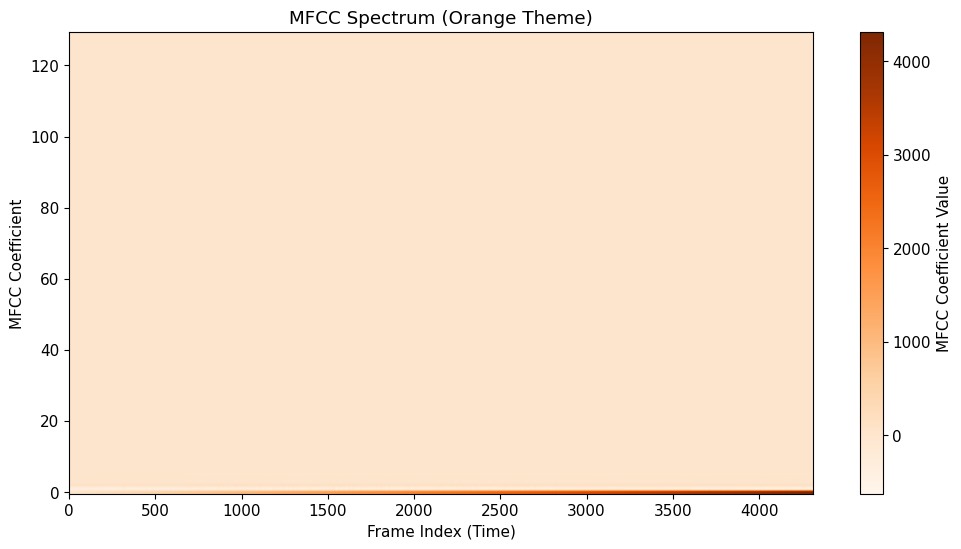

In [33]:
import pandas as pd
import matplotlib.pyplot as plt

# Load your MFCC CSV file
df = pd.read_csv("/kaggle/input/mfcc-of-slurred-vocal/MFCCoutput.csv")

# Convert to numpy array (samples × coefficients)
mfcc = df.values.T   # transpose so coeffs go on y-axis

# Plot heatmap in orange
plt.figure(figsize=(12, 6))
plt.imshow(mfcc, aspect='auto', origin='lower', cmap='Oranges')
plt.colorbar(label="MFCC Coefficient Value")
plt.xlabel("Frame Index (Time)")
plt.ylabel("MFCC Coefficient")
plt.title("MFCC Spectrum (Orange Theme)")
plt.show()


<Figure size 5000x5120 with 0 Axes>

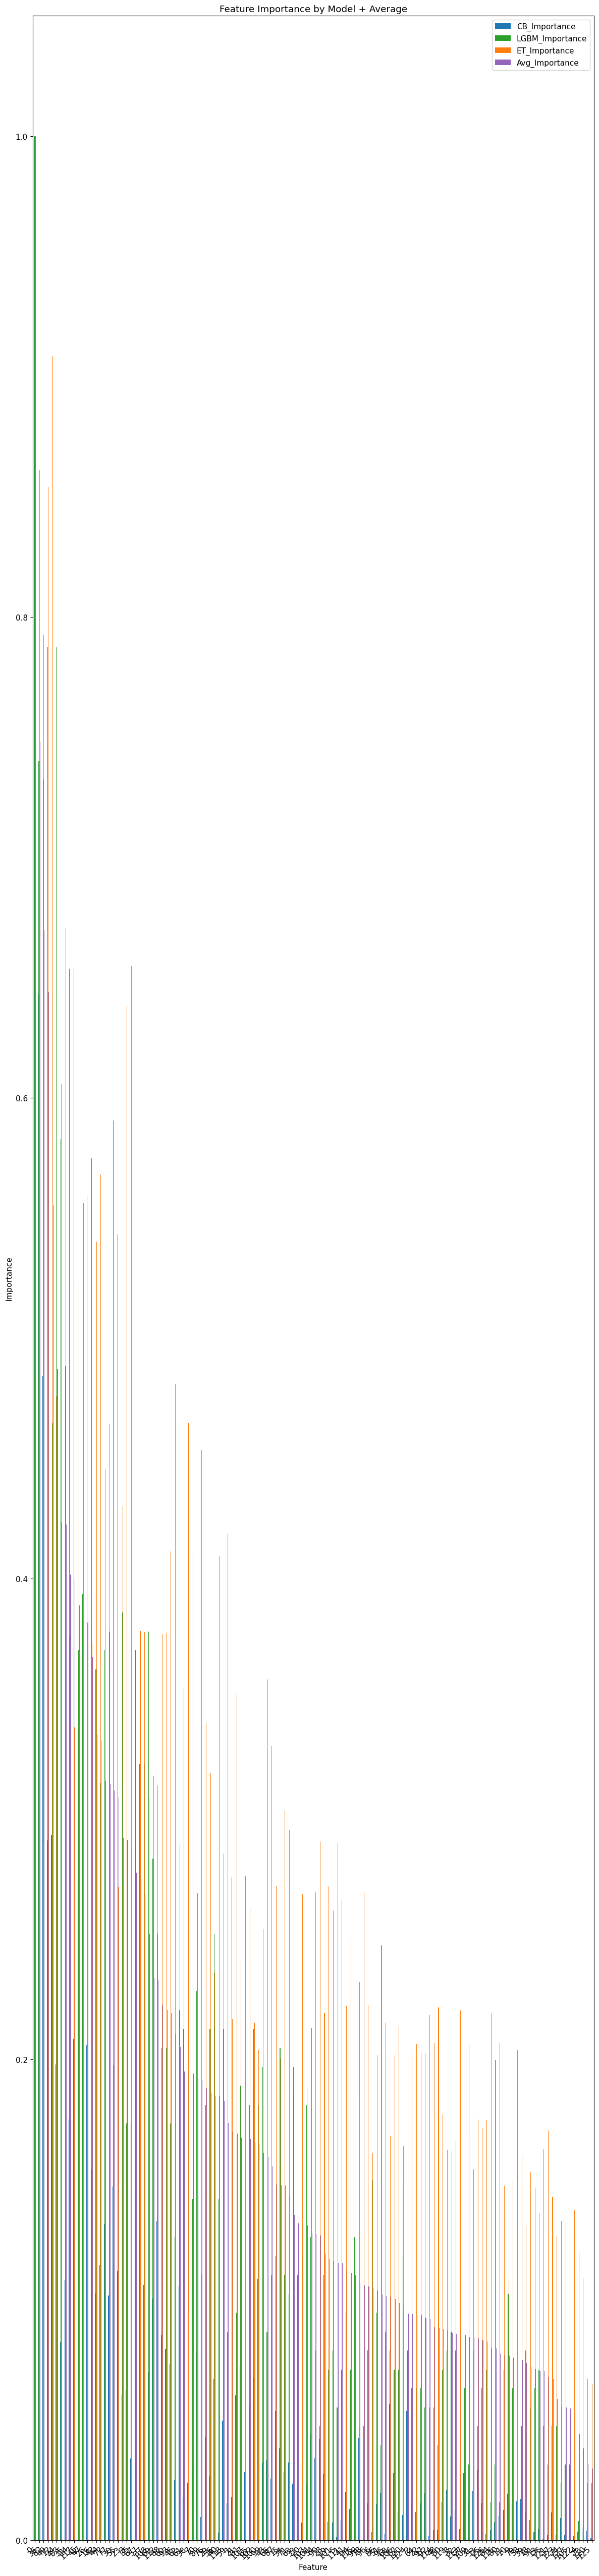

In [35]:
import matplotlib.pyplot as plt

# Set Feature column as index
importance_df_plot = importance_df.set_index("Feature")

# Sort by Avg_Importance
importance_df_plot = importance_df_plot.sort_values("Avg_Importance", ascending=False)

# Select only model importances + Avg
plot_cols = ["CB_Importance", "LGBM_Importance", "ET_Importance", "Avg_Importance"]

# Define colors (avoid red)
custom_colors = ["#1f77b4",  # CatBoost - blue
                 "#2ca02c",  # LGBM - green
                 "#ff7f0e",  # ExtraTrees - orange
                 "#9467bd"]  # Avg - purple

# Plot grouped bar chart
plt.figure(figsize=(50, max(5, 0.4*len(importance_df_plot))))
importance_df_plot[plot_cols].plot(
    kind="bar",
    figsize=(12, max(5, 0.4*len(importance_df_plot))),
    color=custom_colors
)

plt.ylabel("Importance")
plt.xlabel("Feature")
plt.title("Feature Importance by Model + Average")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [ ]:
df_sorted = importance_df.sort_values("Avg_Importance", ascending=True)

plt.figure(figsize=(10, 12))
plt.barh(df_sorted["Feature"], df_sorted["Avg_Importance"], color="#9467bd")
plt.xlabel("Avg Importance")
plt.title("Feature Importance (Average Across Models)")
plt.tight_layout()
plt.show()


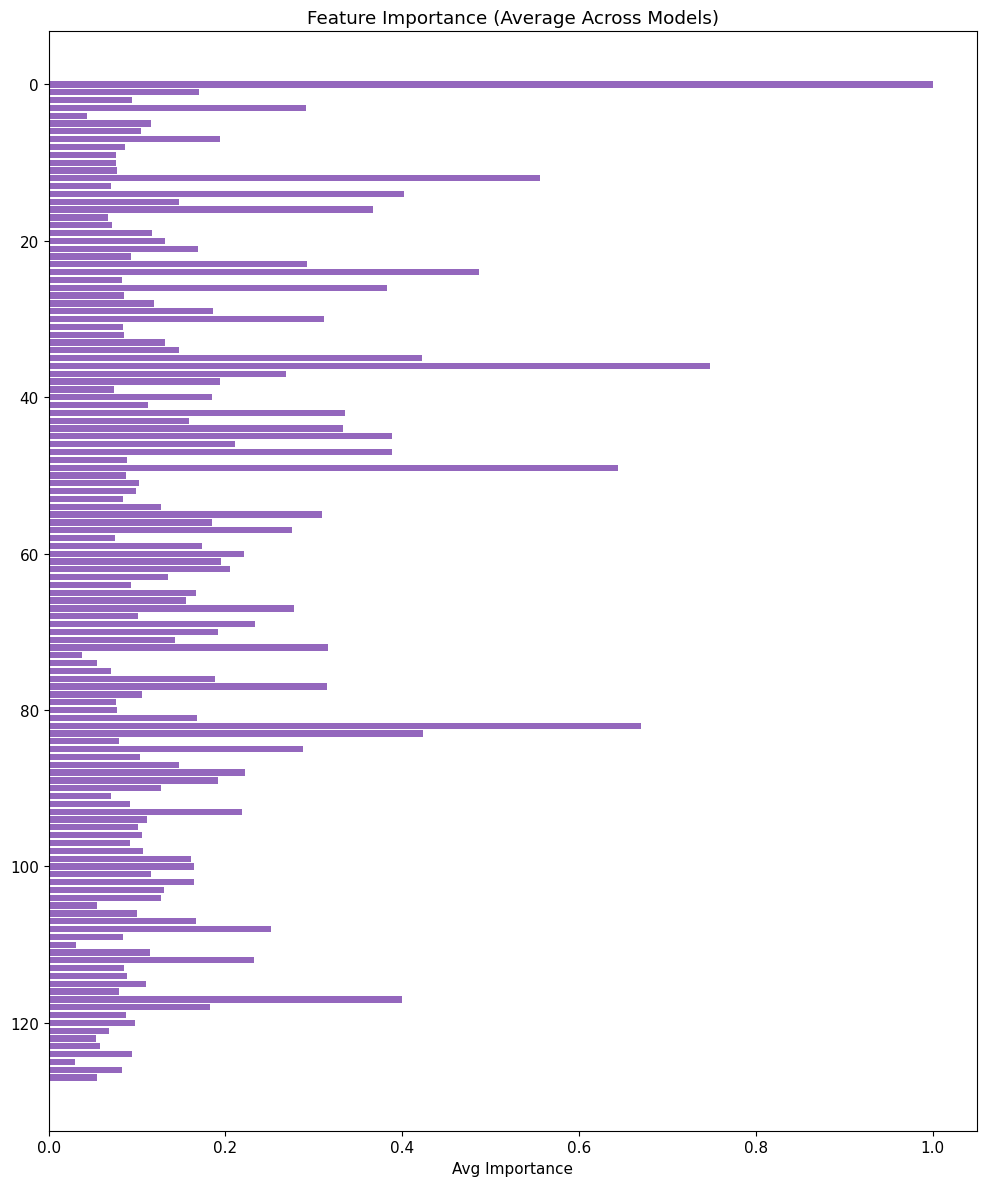

In [36]:
# Sort by Avg_Importance descending
df_sorted = importance_df.sort_values("Avg_Importance", ascending=False)

plt.figure(figsize=(10, 12))
plt.barh(df_sorted["Feature"], df_sorted["Avg_Importance"], color="#9467bd")
plt.xlabel("Avg Importance")
plt.title("Feature Importance (Average Across Models)")

# Flip y-axis so the most important is at the top
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()


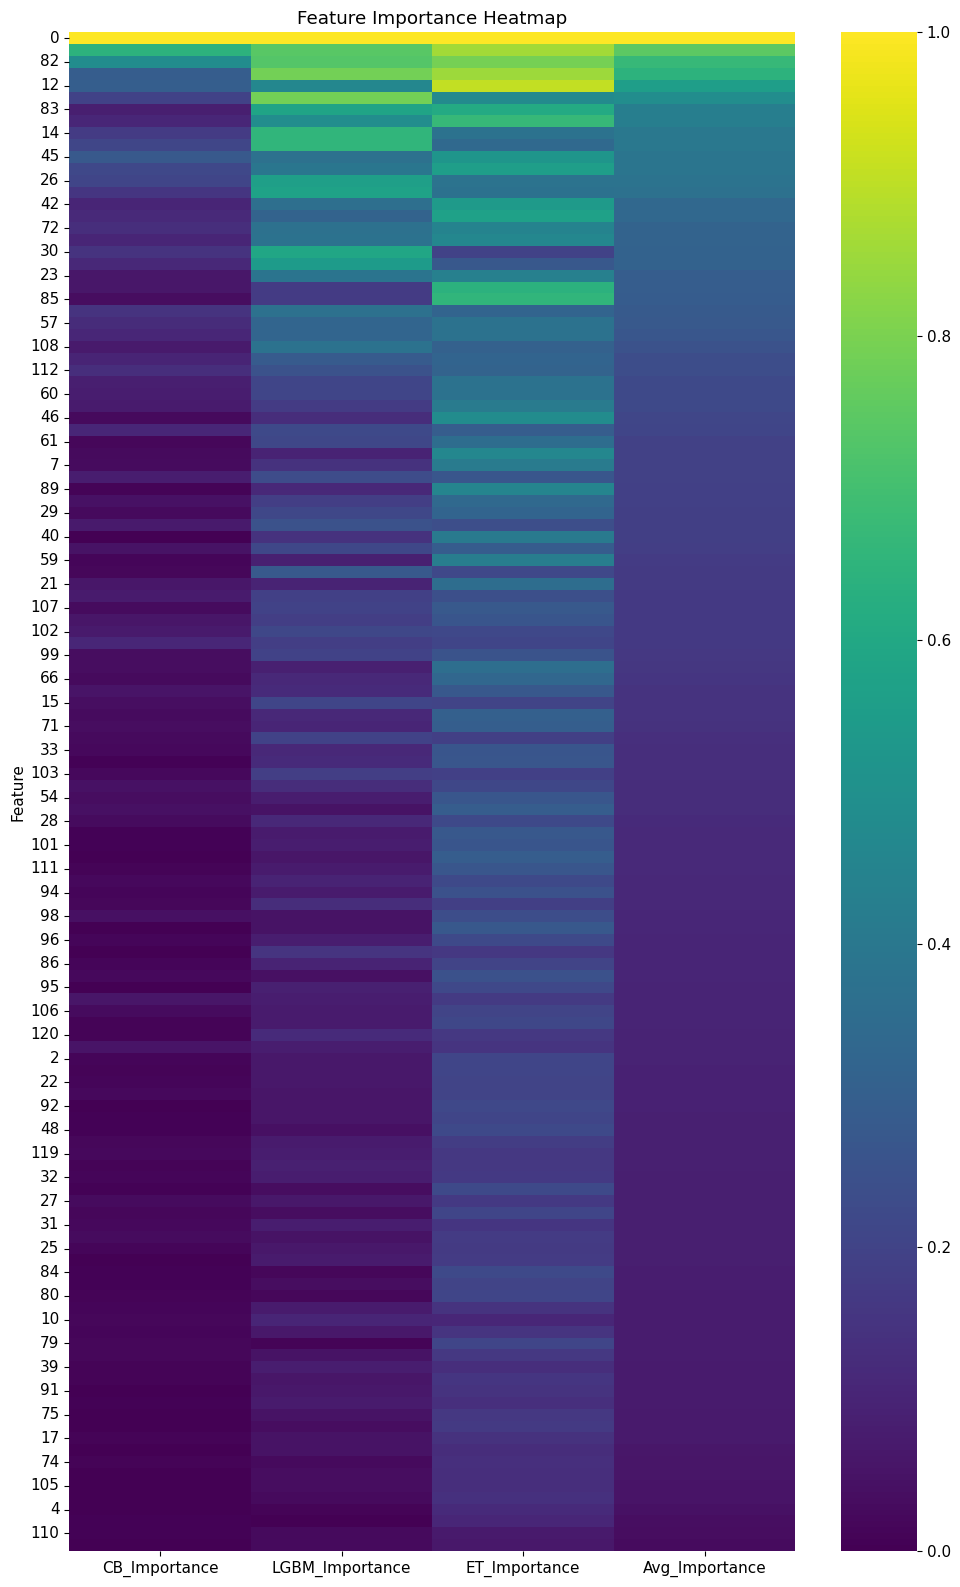

In [39]:
import seaborn as sns

df_heat = importance_df.set_index("Feature")[["CB_Importance","LGBM_Importance","ET_Importance","Avg_Importance"]]
df_heat_sorted = df_heat.sort_values("Avg_Importance", ascending=False)

plt.figure(figsize=(10, 16))
sns.heatmap(df_heat_sorted, cmap="viridis", annot=False)
plt.title("Feature Importance Heatmap")
plt.tight_layout()
plt.show()


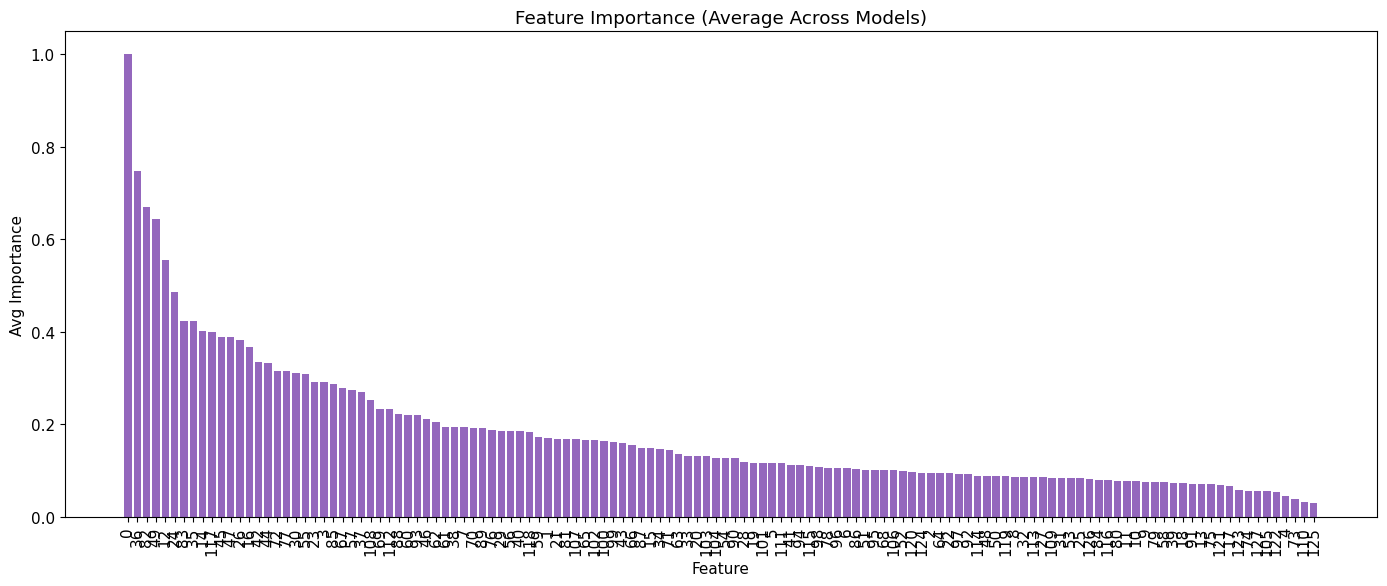

In [40]:
# Sort by Avg_Importance descending
df_sorted = importance_df.sort_values("Avg_Importance", ascending=False)

plt.figure(figsize=(14, 6))
plt.bar(df_sorted["Feature"].astype(str), df_sorted["Avg_Importance"], color="#9467bd")
plt.ylabel("Avg Importance")
plt.xlabel("Feature")
plt.title("Feature Importance (Average Across Models)")
plt.xticks(rotation=90)  # rotate so labels don’t overlap
plt.tight_layout()
plt.show()


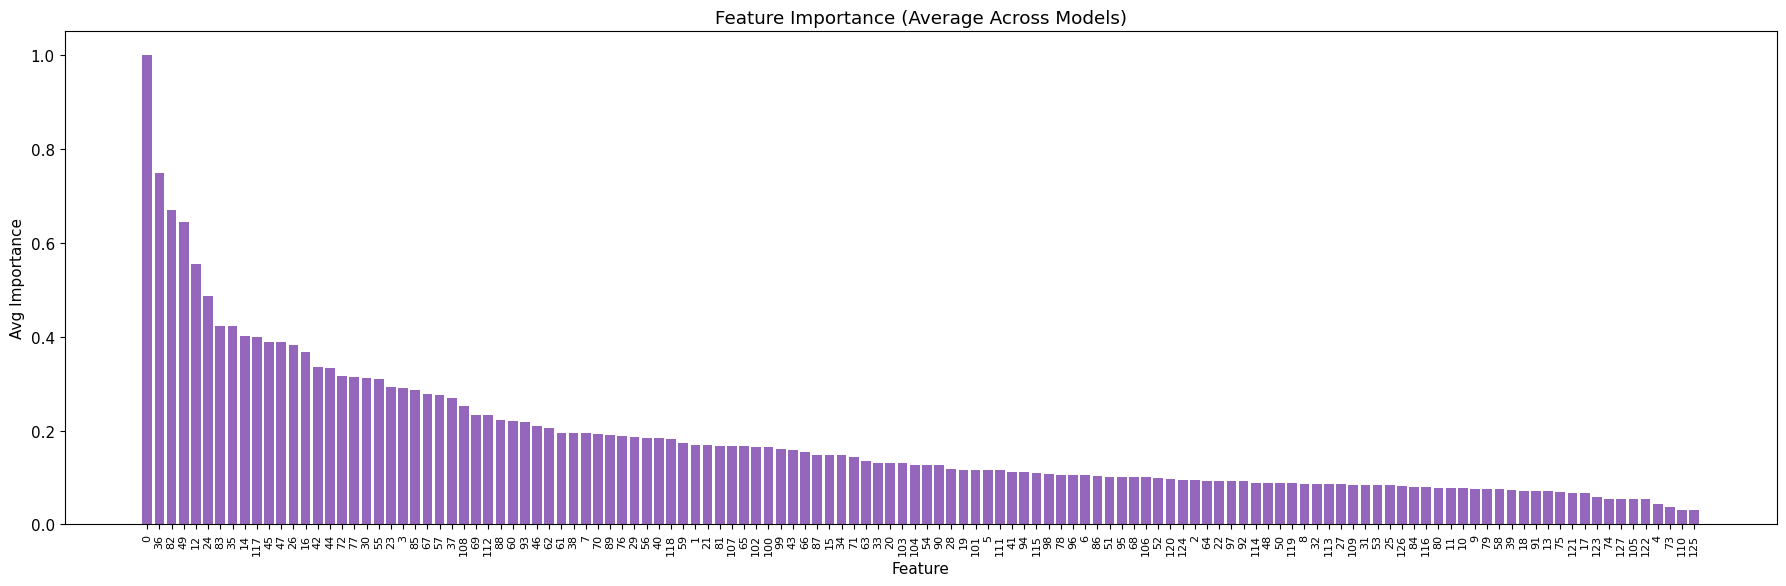

In [41]:
df_sorted = importance_df.sort_values("Avg_Importance", ascending=False)

plt.figure(figsize=(18, 6))
plt.bar(df_sorted["Feature"].astype(str), df_sorted["Avg_Importance"], color="#9467bd")
plt.ylabel("Avg Importance")
plt.xlabel("Feature")
plt.title("Feature Importance (Average Across Models)")
plt.xticks(rotation=90, fontsize=8)  # rotate & shrink
plt.tight_layout()
plt.show()


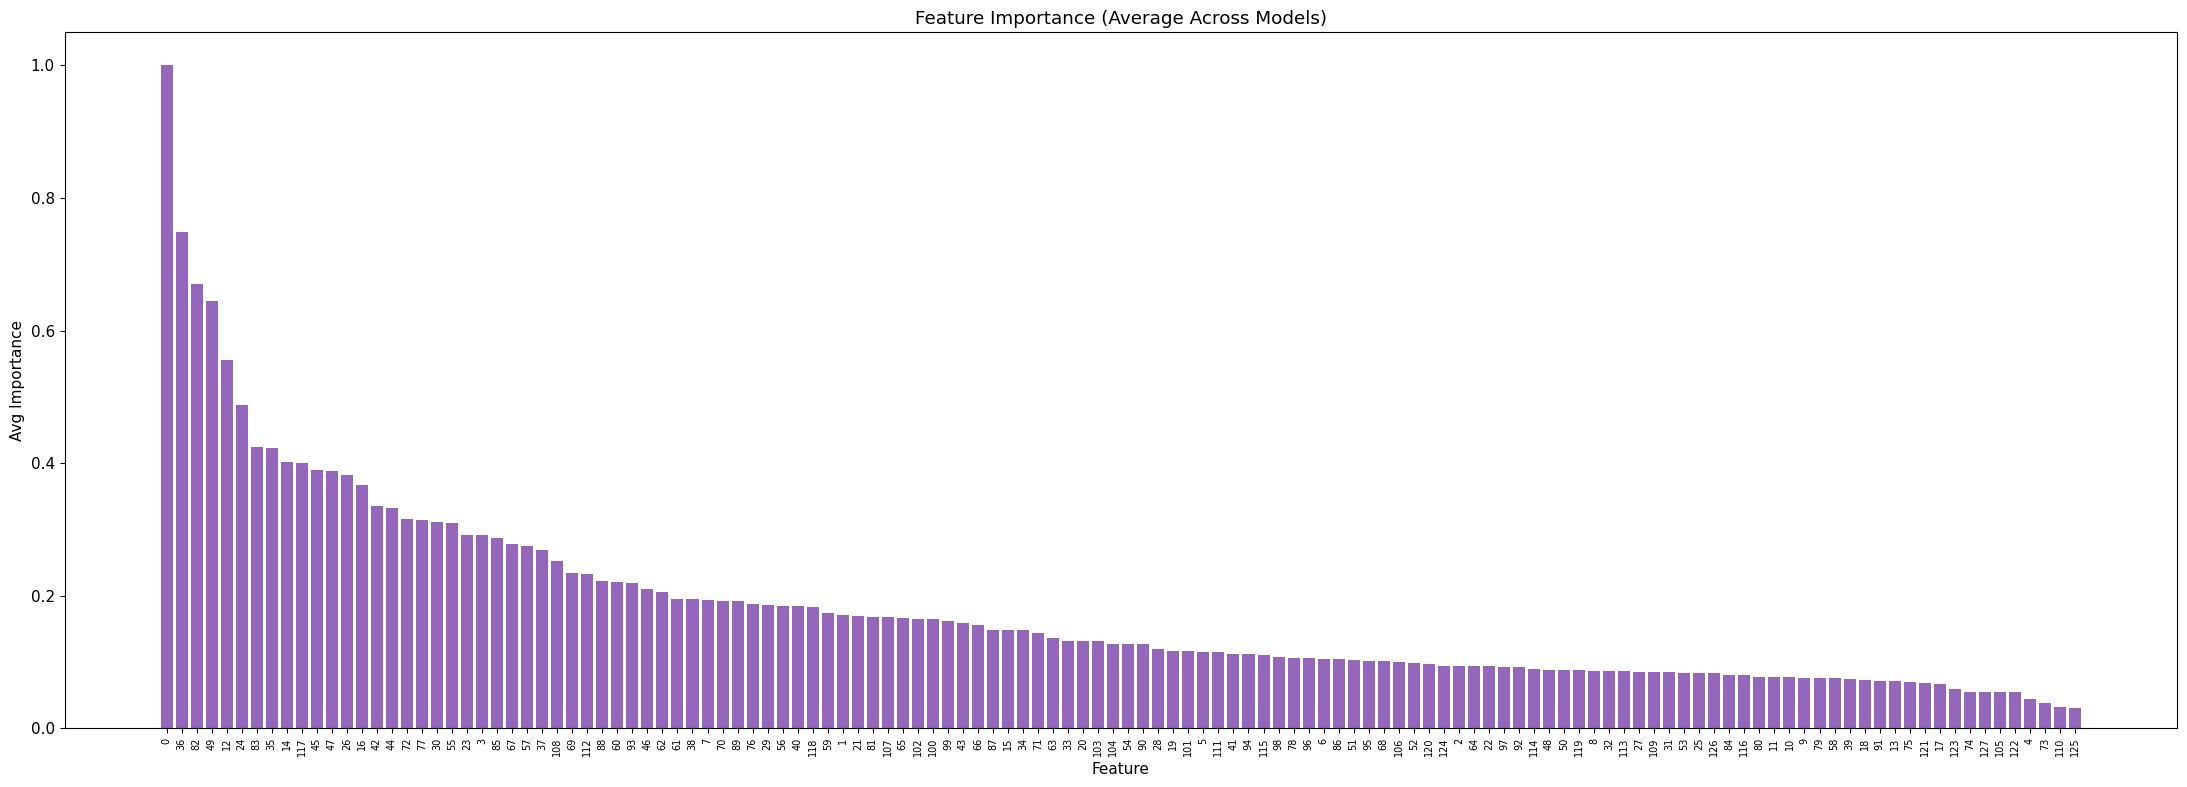

In [42]:
import matplotlib.pyplot as plt

# Sort all features by Avg_Importance
df_sorted = importance_df.sort_values("Avg_Importance", ascending=False)

plt.figure(figsize=(22, 8))  # wider so labels breathe
plt.bar(df_sorted["Feature"].astype(str), df_sorted["Avg_Importance"], color="#9467bd")
plt.ylabel("Avg Importance")
plt.xlabel("Feature")
plt.title("Feature Importance (Average Across Models)")
plt.xticks(rotation=90, fontsize=7)  # vertical labels, smaller font

# Save as high-res
plt.tight_layout()
plt.savefig("feature_importance_all.png", dpi=400)   # PNG high-res
plt.savefig("feature_importance_all.pdf")            # vector version
plt.show()


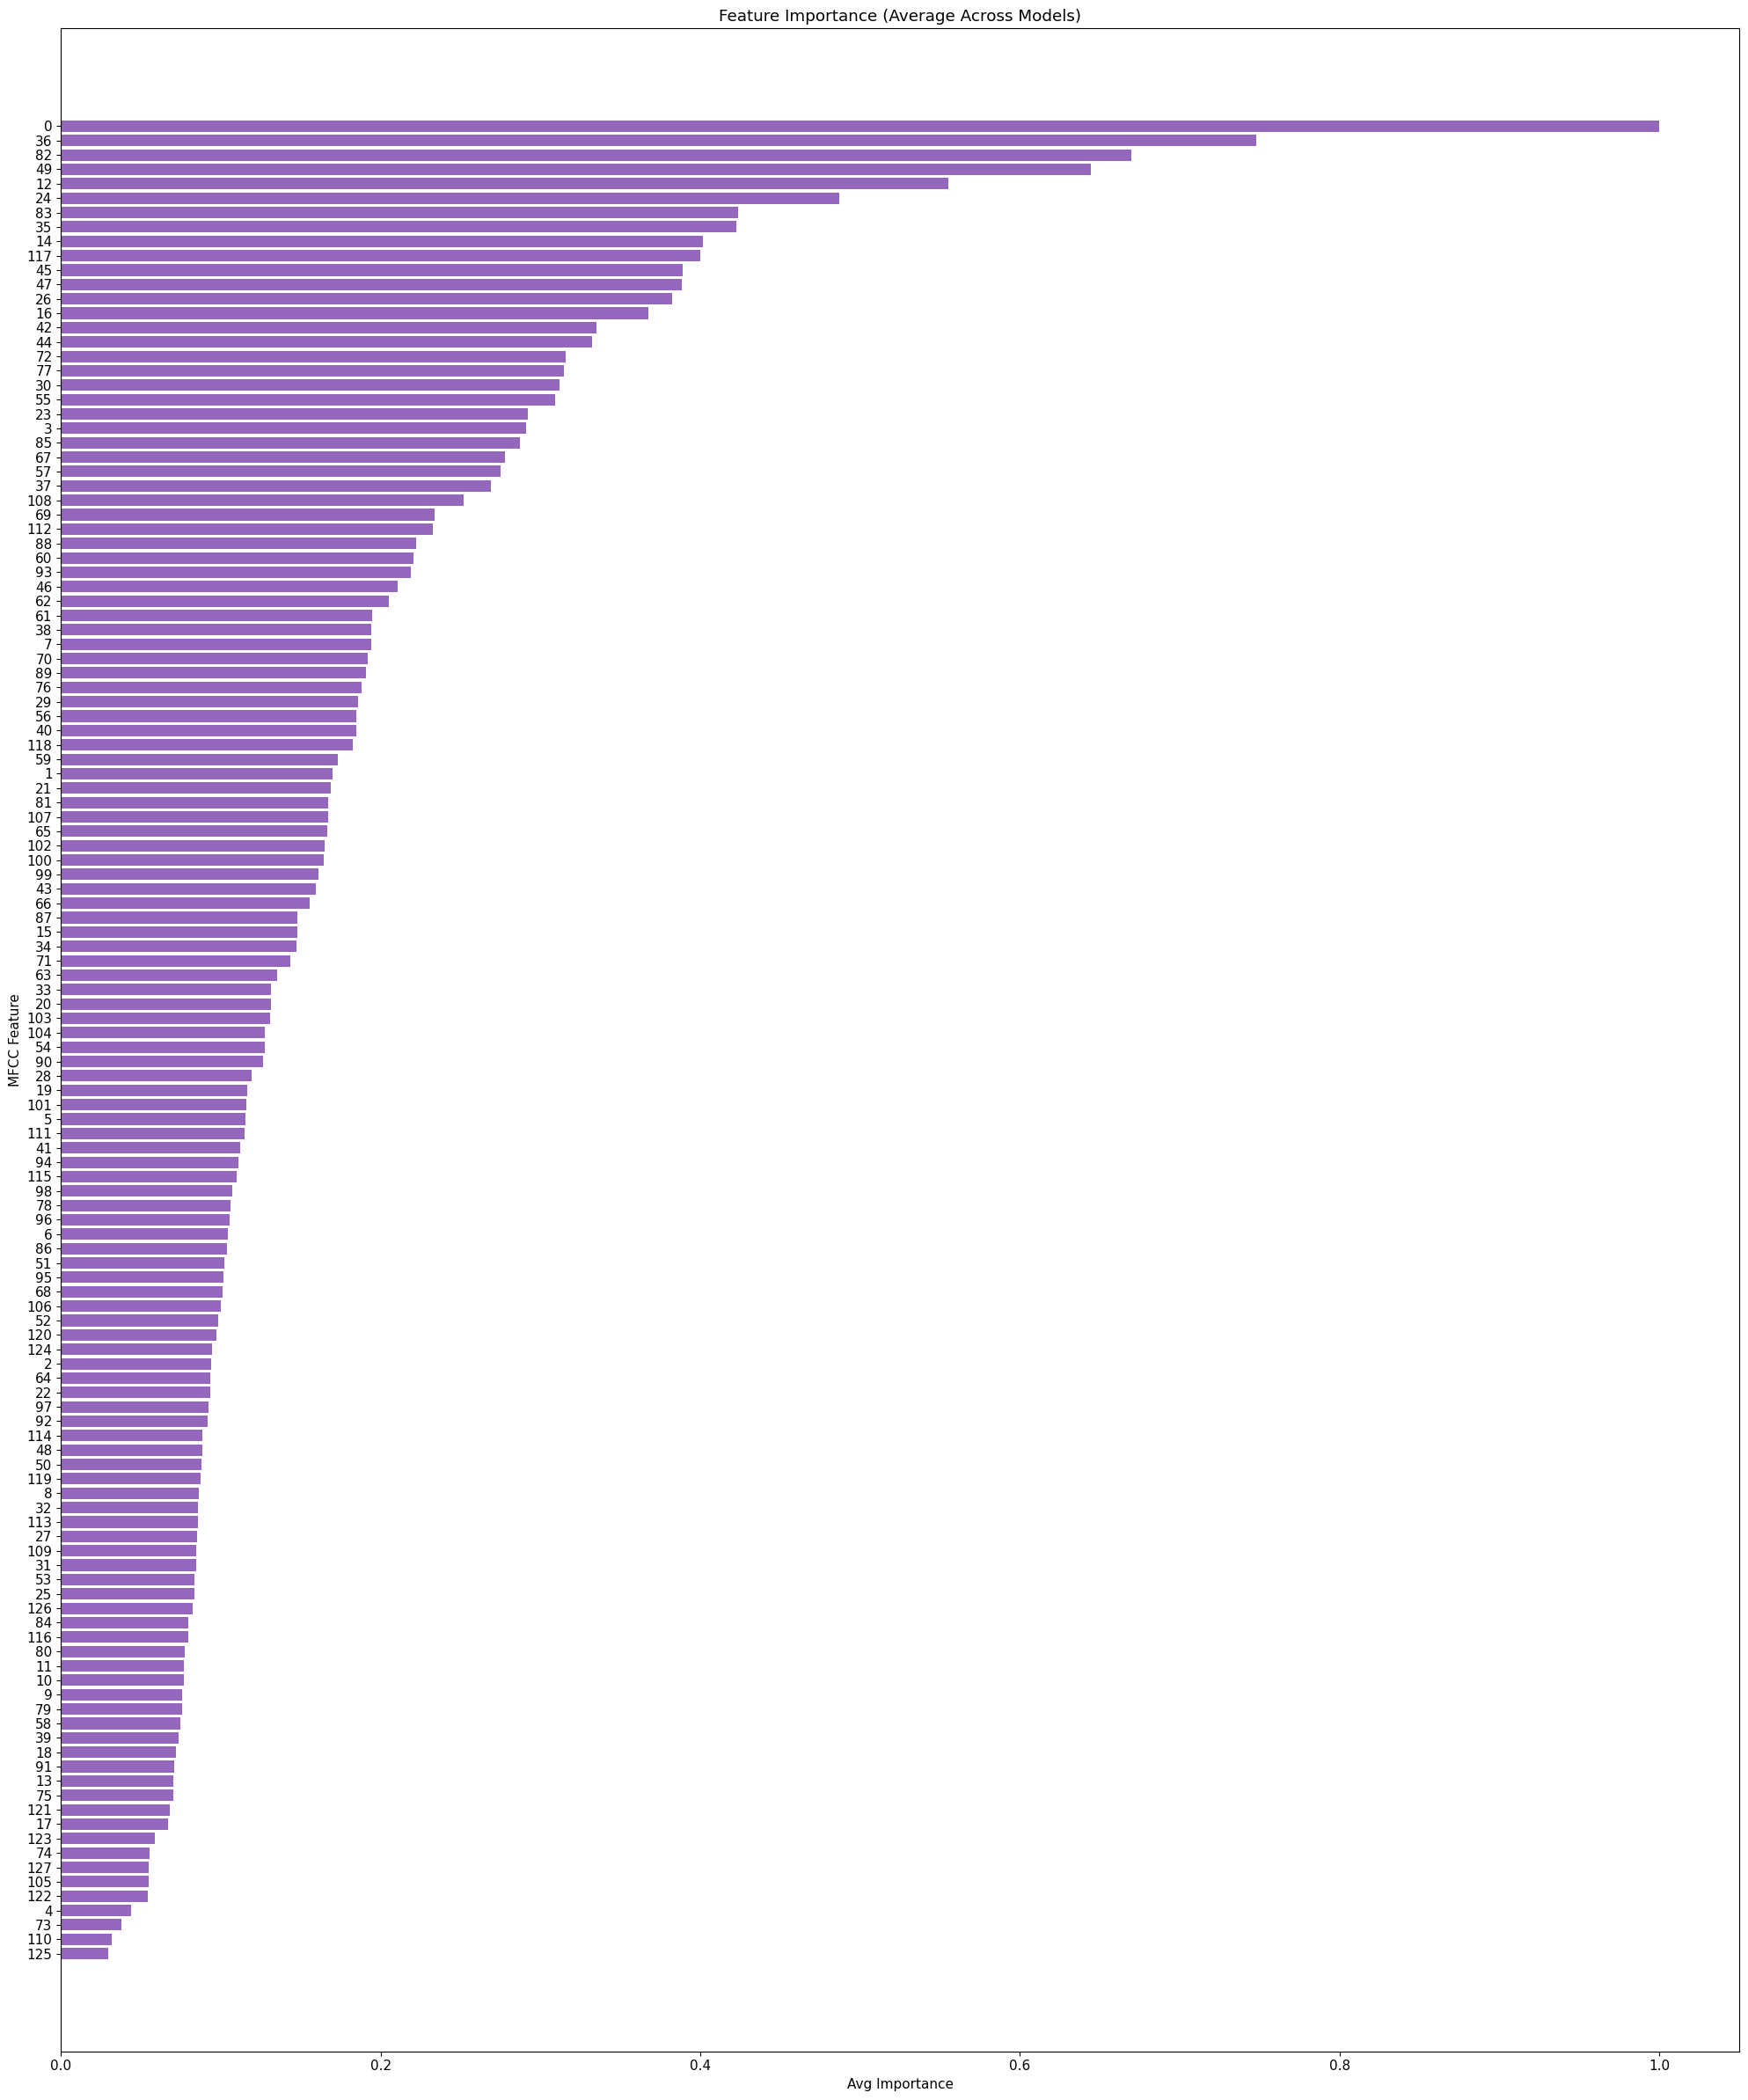

In [43]:
import matplotlib.pyplot as plt

# Sort all features by Avg_Importance
df_sorted = importance_df.sort_values("Avg_Importance", ascending=True)

plt.figure(figsize=(20, 24))  # tall enough for 116 features
plt.barh(df_sorted["Feature"].astype(str), df_sorted["Avg_Importance"], color="#9467bd")
plt.xlabel("Avg Importance")
plt.ylabel("MFCC Feature")
plt.title("Feature Importance (Average Across Models)")

# Save high-res
plt.tight_layout()
plt.savefig("mfcc_feature_importance_all_horizontal.png", dpi=400)  # PNG high-res
plt.savefig("mfcc_feature_importance_all_horizontal.pdf")           # vector version
plt.show()
